# 08 · Karar Ağaçları (Decision Trees)
**Classical ML Lab** · CART, Saflık Ölçütleri, Budama ve Yorumlanabilirlik

---
> **Bu notebook'ta ne öğreneceğiz?**
> Şimdiye kadarki tüm modeller (`03_linear_classification_family`, `04_linear_regression_family`, `05_knn_instance_based`, `06_naive_bayes_family`, `07_svm_kernels`) ya doğrusal bir karar sınırı öğrendi, ya olasılık modelledi, ya da tüm eğitim verisine mesafeye dayalı baktı. **Karar Ağaçları (Decision Trees)**, tamamen farklı ve son derece sezgisel bir felsefeyle yaklaşır: veriyi, her adımda "en bilgilendirici" tek bir soru sorarak (`yaş > 45 mi?`, `göğüs ağrısı tipi nedir?`) tekrar tekrar ikiye böler — tıpkı bir doktorun teşhis koyarken veya bir kredi uzmanının başvuru değerlendirirken izlediği akış şeması gibi. Bu basit fikir, **CART (Classification and Regression Trees)** algoritmasıyla matematiksel bir çerçeveye oturur ve hem sınıflandırma hem regresyon problemlerini tek bir çatı altında çözer. Karar ağaçları, modern ML'de tek başına nadiren en yüksek doğruluğu verse de, **Random Forest, Gradient Boosting, XGBoost/LightGBM/CatBoost gibi bir sonraki iki notebook'ta göreceğimiz en güçlü yöntemlerin temel yapı taşıdır** — onları anlamadan ensemble yöntemlerini gerçekten kavramak mümkün değildir. Bu notebook'ta: (1) Gini/Entropi saflık ölçütlerini ve bilgi kazancını sıfırdan elle hesaplayacağız, (2) CART'ın sınıflandırma ve regresyon versiyonlarını sıfırdan kodlayıp `scikit-learn` ile doğrulayacağız, (3) aşırı öğrenmeyi önlemek için ön-budama ve maliyet-karmaşıklık (cost-complexity) budamasını gerçek veride uygulayacağız, ve (4) özellik önemini (feature importance) hem sınıflandırma hem regresyon bağlamında yorumlayacağız.
>
> **Önkoşul:** `03_linear_classification_family` (temel sınıflandırma kavramları), temel olasılık (`Probability-lab`), `01_data_prepreparation/02_data_preprocessing` (eksik veri, kategorik encoding — burada tekrar karşımıza çıkacak).
> **Veri:** UCI Heart Disease (Cleveland — kalp hastalığı teşhisi, ikili sınıflandırma, 303 örnek), UCI Adult Census Income (gelir tahmini, ikili sınıflandırma, 48.842 örnek — aşırı öğrenme/budama için büyük veri), UCI Bike Sharing (günlük bisiklet kiralama talebi, regresyon, 731 örnek).
> **Araçlar:** Python (`scikit-learn` — `DecisionTreeClassifier`, `DecisionTreeRegressor`, ayrıca sıfırdan CART implementasyonu), R (`rpart`, `rpart.plot` — kategorik değişkenleri native destekleyen alternatif), SQL (DuckDB — Gini/SSE hesaplarının SQL'de yeniden üretimi).

---
## 1 · Karar Ağaçlarına Giriş: Sezgi ve Terminoloji

Bir karar ağacı, veriyi bir dizi **ikili soru (binary question)** ile art arda bölerek sınıflandırma veya regresyon yapan, akış-şeması benzeri bir modeldir. Örneğin Heart Disease veri setinde: "*Göğüs ağrısı tipi (`cp`) asemptomatik mi?*" → evet ise "*Egzersizde anjina (`exang`) var mı?*" → ... şeklinde dallanarak sonunda bir tahmine (yaprak düğüm) ulaşılır.

**Terminoloji:**
- **Kök düğüm (root node):** Tüm veriyi içeren, ilk bölünmenin yapıldığı en üst düğüm.
- **İç düğüm (internal/decision node):** Bir özellik üzerinde bir eşik/koşulla veriyi ikiye bölen düğüm.
- **Yaprak düğüm (leaf/terminal node):** Artık bölünmeyen, nihai tahmini (sınıflandırmada çoğunluk sınıfı, regresyonda ortalama) taşıyan düğüm.
- **Derinlik (depth):** Kökten bir düğüme kadar olan bölünme sayısı.
- **Budama (pruning):** Aşırı öğrenmeyi azaltmak için ağacı küçültme işlemi (Bölüm 5).

Bir ağaç, özellik uzayını (feature space) eksenlere paralel dikdörtgen bölgelere ayırır — bu, Lojistik Regresyon'un tek bir düz/eğrisel sınırından ("global" karar sınırı) temelde farklıdır: karar ağacı **parçalı-sabit (piecewise constant)**, tamamen doğrusal olmayan ve **yerel (local)** bir karar yapısı öğrenir. Bölme işlemi **açgözlü (greedy)** ve **özyinelemeli (recursive)**'dir: her düğümde, o anki veri alt kümesi için "en iyi" tek bölünme aranır (gelecekteki bölünmeler hesaba katılmadan) — bu yüzden algoritmaya **açgözlü özyinelemeli ikili bölme (greedy recursive binary splitting)** denir. Global optimum garanti edilmez (NP-tam bir problemdir), ama pratikte çok hızlı ve etkili çalışır.

**Neden hâlâ önemli?** Tek başına bir karar ağacı günümüzde nadiren üretimde (production) tek model olarak kullanılır — ama **Random Forest** (`09_bagging_random_forest`) ve **Gradient Boosting/XGBoost/LightGBM** (`10_gradient_boosting_family`) gibi en güçlü tablo-veri (tabular data) yöntemlerinin **hepsi**, temel yapı taşı olarak karar ağacını kullanır. Bu yöntemleri gerçekten anlamak, önce tek bir ağacın nasıl kurulduğunu, nerede zayıf kaldığını (yüksek varyans, kararsızlık) ve neden bir "orman"a ihtiyaç duyulduğunu anlamaktan geçer.

**Endüstride nerede kullanılır?** Karar ağaçları, **yorumlanabilirliğin (interpretability)** doğruluktan daha kritik olduğu regüle sektörlerde hâlâ tercih edilir: kredi/kart başvuru red gerekçesi yasal olarak açıklanabilir olmalıdır (ABD'de Equal Credit Opportunity Act), bu yüzden bankalar genellikle tek bir sığ karar ağacını veya ağaçtan türetilmiş "skorkart kuralları"nı kullanır; tıpta klinik karar destek sistemleri (örn. göğüs ağrısı triyaj protokolleri) doğrudan karar ağacı/akış şeması biçiminde tasarlanır çünkü hekimler adım adım takip edebilmelidir; üretim hatlarında arıza teşhis ağaçları (fault-diagnosis trees) bakım teknisyenlerine "önce şunu kontrol et, sonucuna göre şuna bak" şeklinde rehberlik eder.

---
## 2 · Saflık (Impurity) Ölçütleri: Gini Index, Entropi ve Bilgi Kazancı

CART'ın her adımda çözmesi gereken soru: *"Hangi özellik, hangi eşik değeriyle bölünürse, ortaya çıkan iki alt küme en 'saf' (pure) olur?"* Bir düğüm **saf**tır eğer içindeki tüm örnekler aynı sınıfa aitse. Saflığı sayısallaştırmak için üç yaygın ölçüt kullanılır (ikili sınıflandırma için, $p$ = pozitif sınıfın oranı):

**1. Gini Index (Gini Impurity)** — CART'ın (ve `scikit-learn`'ün varsayılanının) kullandığı ölçüt:
$$G = 1 - \sum_{k=1}^{K} p_k^2 = \sum_{k \ne k'} p_k p_{k'}$$
İkili durumda: $G = 1 - (p^2 + (1-p)^2) = 2p(1-p)$. $G=0$ tamamen saf (tek sınıf), $G=0.5$ (ikili sınıflandırmada) en karışık durumdur ($p=0.5$). Yorumu: rastgele iki örnek çekip rastgele etiketlersek yanlış etiketleme olasılığıdır.

**2. Entropi (Shannon Entropy)** — bilgi teorisinden gelir, ID3/C4.5 algoritmalarının (ve isteğe bağlı olarak `scikit-learn`'ün) kullandığı ölçüt:
$$H = -\sum_{k=1}^{K} p_k \log_2 p_k$$
İkili durumda maksimumu $H=1$ bit'tir ($p=0.5$'te). **Bilgi Kazancı (Information Gain)**, bir bölünmenin entropiyi ne kadar azalttığıdır: $IG = H(\text{ebeveyn}) - \sum_{c} \frac{n_c}{n} H(c)$ (çocuk düğümlerin ağırlıklı ortalama entropisi çıkarılır).

**3. Sınıflandırma Hatası (Classification/Misclassification Error):** $E = 1 - \max_k(p_k)$. Diğer ikisinden daha az duyarlı (less sensitive) olduğu için pratikte **bölünme ararken** nadiren kullanılır (Gini/Entropi'nin türevi düğümdeki değişime daha duyarlıdır, bu yüzden daha "iyi" bölünmeler bulur) — ama budanmış ağacın nihai performansını **değerlendirirken** doğal bir metriktir.

Gini ve Entropi neredeyse her zaman aynı bölünmeyi seçer (eğrileri çok benzer şekillidir, Entropi biraz daha "cezalandırıcı"dır) — pratikte fark genellikle küçüktür; Gini hesaplama olarak biraz daha hızlıdır (logaritma yok).

**Elle hesaplanmış gerçek örnek (Heart Disease veri seti, kök düğüm):** 303 hastanın $%54.46$'sında ($n_1=165$) kalp hastalığı var (`target=1`), $%45.54$'ünde ($n_0=138$) yok. Kök düğümde:
$$G_{kök} = 1-(0.5446^2+0.4554^2) = 0.4960 \qquad H_{kök} = -(0.5446\log_2 0.5446 + 0.4554\log_2 0.4554) = 0.9943 \text{ bit}$$
`exang` (egzersizde anjina var mı, 0/1) özelliğiyle bölersek: `exang=0` grubunda ($n=204$) hastalık oranı $%69.61$ ($G=0.4231$, $H=0.8860$), `exang=1` grubunda ($n=99$) hastalık oranı $%23.23$ ($G=0.3567$, $H=0.7820$) — yani bu tek soru bile hastalık olasılığını neredeyse üçe katlıyor/yarıya indiriyor. Ağırlıklı ortalama:
$$G_{sonra} = \tfrac{204}{303}(0.4231) + \tfrac{99}{303}(0.3567) = 0.4014 \;\Rightarrow\; \Delta G = 0.4960-0.4014 = 0.0946$$
$$H_{sonra} = \tfrac{204}{303}(0.8860) + \tfrac{99}{303}(0.7820) = 0.8521 \;\Rightarrow\; IG = 0.9943-0.8521 = 0.1422 \text{ bit}$$
CART, tüm özellikler ve tüm olası eşikler arasında $\Delta G$'yi (ya da $IG$'yi) **maksimize eden** bölünmeyi seçer — Python 2'de bunu tam olarak sıfırdan arayıp gerçekten `exang`'in (ya da daha iyi bir adayın) kazanıp kazanmadığını göreceğiz.

![image](data/gini_saflik_karsilastirmasi.svg)
**Örnekli Açıklama:** Görseldeki üç çubuğa bak: her biri bir grubu temsil ediyor, turuncu kısım "hastalık var" oranı, yeşil kısım "hastalık yok" oranı. Gini değeri aslında şunu ölçüyor: bu çubuk ne kadar tek renge yakın?

- Çubuk yarı yarıya iki renkse (turuncu ≈ yeşil), Gini en yüksek noktaya (binary'de 0.5) yaklaşır — bu "kötü", çünkü grup hâlâ tamamen karışık, tahmin etmek zor.
- Çubuk neredeyse tek renkse, Gini 0'a yaklaşır — bu "iyi", çünkü artık gruptaki neredeyse herkes aynı sınıfta.

Kök düğümde (üstteki çubuk) iki renk neredeyse yarı yarıya, Gini=0.496 — 0.5'in hemen altında, yani en kötüye yakın bir durum. exang=1 grubunda (alttaki çubuk) yeşil bariz baskın, Gini=0.357 — daha saf, daha iyi. Cetveldeki üç nokta da bunu gösteriyor: sağa gittikçe (0.5'e yaklaştıkça) kötüleşiyor, sola gittikçe (0'a yaklaştıkça) iyileşiyor.

Ama asıl kritik nokta şu: tek bir Gini değeri kendi başına "iyi" ya da "kötü" değildir — önemli olan bölünmeden önceki (kök) değerle sonraki (çocuk) değerleri karşılaştırmak. CART, bu karşılaştırmadaki düşüşü (kazancı) maksimize eden bölünmeyi arıyor.

**Peki** eğer bir bölünme kök düğümün Gini'sini 0.496'dan sadece 0.49'a indirseydi (neredeyse hiç değişmeseydi) gruplar hâlâ neredeyse yarı yarıya karışık, yani o bölünme pratikte bir işe yaramamış demek.

İşte tam burası notebook'taki $\Delta G$ (Gini kazancı) dediğimiz şeyde budur. Örnekte $\Delta G = 0.496 - 0.490 = 0.06$ küçük bir kazanç olduğu için ama başka türlü kazancımız $\Delta G = 0.496 - 0.401 = 0.095$ olursa o zaman daha iyi bölünme olarak bunu alırız. CART her düğümde tam olarak bunu yapıyor: tüm olası bölünmeler arasında bu $\Delta G$'yi en büyük yapanı seçiyor.

![image](data/gini_entropi_olcek_karsilastirmasi.svg)
**Açıklama:** Entropi de tam olarak aynı "karışıklık termometresi" — sadece formülü farklı. $log_2$ boşuna değil, bilgi teorisinden geliyor: entropi, "bu gruptaki bir örneğin sınıfını öğrenmek için ortalama kaç tane evet/hayır sorusuna ihtiyacım var" sorusunun cevabı. Grup tamamen saf ise (herkes aynı sınıfta) hiç soru sormana gerek yok → 0 bit. Grup ikili bir sınıflandırmada tam yarı yarıya karışıksa, tek bir iyi soru bile seni %50 belirsizlikten kurtaramaz → maksimum 1 bit.

İşte bu yüzden ölçekler farklı görünüyor: Gini binary'de en fazla 0.5'e çıkarken, entropi en fazla 1 bit'e çıkıyor. Ama görseldeki iki cetvele bak — üç nokta da (kök, exang=0, exang=1) her iki cetvelde de aynı sırada. Yani hangi ölçütü kullanırsan kullan, "hangi bölünme daha iyi" sorusunun cevabı genelde değişmiyor — tam da bu yüzden notebook'ta ikisi de kök düğümde aynı özelliği (cp) seçti.

**Gini'de $\Delta G$ neyse, entropide Bilgi Kazancı (Information Gain)'de $IG = H_\text{kök} - H_\text{sonra}$ Büyük bir düşüş = iyi bölünme, küçük/hiç düşüş = kötü bölünme — kural değişmiyor, sadece cetveldeki sayılar değişiyor.**

**Endüstride nerede kullanılır?** Bilgi kazancı kavramı karar ağaçlarının ötesine taşar: A/B test analizinde "hangi kullanıcı segmenti dönüşüm oranını en çok açıklıyor" sorusu, pazarlamada müşteri segmentasyon ağaçlarında "hangi demografik/davranışsal özellik satın alma olasılığını en çok ayırt ediyor" sorusu, hep aynı Gini/Entropi mantığıyla çözülür; medikal teşhiste hangi semptomun/test sonucunun teşhisi en çok netleştirdiğini (en yüksek bilgi kazancını) bulmak, triyaj protokollerinin tasarımında doğrudan kullanılır.

---
## 3 · CART Algoritması: Sınıflandırma Ağaçları (Recursive Binary Splitting)

CART her düğümde şu algoritmayı çalıştırır:

1. **Aday bölünmeleri üret:** Her sayısal özellik $j$ için, o düğümdeki verideki ardışık farklı değerlerin orta noktaları aday eşik ($t$) değerleridir (örn. `age` için sıralı benzersiz değerler arasındaki orta noktalar). Kategorik bir özellik için, kategorilerin alt kümelerine bölünme aranır (Bölüm 7'de detaylandırılacak — `scikit-learn` bunu native desteklemez).
2. **Her aday $(j, t)$ için saflık kazancını hesapla:** Veriyi $x_j \le t$ ve $x_j > t$ olarak ikiye böl, $\Delta G$ (veya $IG$) hesapla (Bölüm 2).
3. **En yüksek kazancı veren $(j^*, t^*)$'ı seç**, veriyi bu şekilde böl, iki çocuk düğüm oluştur.
4. **Her çocuk düğüm için 1-3'ü özyinelemeli olarak tekrarla**, ta ki bir **durdurma kriteri**ne ulaşılana kadar: düğüm tamamen saf olur ($G=0$), düğümdeki örnek sayısı `min_samples_split`'in altına düşer, maksimum derinliğe (`max_depth`) ulaşılır, veya hiçbir bölünme saflığı `min_impurity_decrease`'den fazla artıramaz.
5. Bir yaprağa ulaşıldığında, tahmin o yapraktaki **çoğunluk sınıfı**dır (olasılık tahmini için sınıf oranları kullanılır).

Bu, tamamen **açgözlü (greedy)** bir arama olduğu için — her adım yalnızca o anki en iyi bölünmeye bakar, ileride daha iyi bir kombinasyon çıkıp çıkmayacağını hesaba katmaz — **global olarak optimal ağacı garanti etmez**. Optimal ikili karar ağacı bulmak NP-tam bir problemdir; CART'ın açgözlü yaklaşımı pratikte çok iyi sonuçlar verir ve $O(n \cdot d \cdot \log n)$ civarında (özellik sayısı $d$, örnek sayısı $n$) verimli çalışır çünkü her özellik düğüme girmeden önce sıralanabilir.

Karmaşıklık sınıfı olarak, tam büyümüş (budanmamış) bir ağaç eğitim verisini **ezberleyebilir** (her yaprakta tek bir örnek kalana kadar bölünmeye devam edebilir) — bu, Bölüm 5'te ele alacağımız aşırı öğrenme sorununun kaynağıdır.

**Endüstride nerede kullanılır?** Sınıflandırma ağaçları, dolandırıcılık tespitinde (fraud detection) "bu işlem şüpheli mi" sorusuna hızlı, açıklanabilir bir ilk-katman filtre olarak (genellikle daha karmaşık bir modelin önünde, düşük gecikmeli bir "kural motoru" gibi) kullanılır; müşteri kaybı (churn) tahmininde pazarlama ekiplerine "hangi müşteri segmenti hangi koşullarda ayrılıyor" sorusunun doğrudan yorumlanabilir bir cevabını verir; sigorta risk sınıflandırmasında (poliçe onay/red) düzenleyici uyumluluk (regulatory compliance) gereği karar mantığının denetlenebilir olması istenir.

---
## 4 · Regresyon Ağaçları: Varyans / SSE Azaltma

CART'ın regresyon versiyonu (**Regression Tree**) aynı özyinelemeli ikili bölme mantığını kullanır, ama saflık ölçütü farklıdır: hedef artık sürekli bir sayı ($y \in \mathbb{R}$) olduğundan Gini/Entropi anlamsızdır. Bunun yerine, bir düğümdeki **Hataların Kareler Toplamı (Sum of Squared Errors, SSE)** kullanılır — düğümün tahmini, o düğümdeki örneklerin ortalamasıdır ($\hat{y} = \bar{y}$), ve saflık bu ortalamadan sapmadır:
$$SSE(\text{düğüm}) = \sum_{i \in \text{düğüm}} (y_i - \bar{y})^2$$

Bir bölünme adayının kalitesi, **SSE azaltmasıyla (SSE reduction / variance reduction)** ölçülür:
$$\Delta SSE = SSE(\text{ebeveyn}) - \left[SSE(\text{sol çocuk}) + SSE(\text{sağ çocuk})\right]$$
CART bu farkı maksimize eden $(j^*, t^*)$'ı seçer — sınıflandırmadaki Gini kazancı maksimizasyonunun tam regresyon karşılığı. Bir yaprağa ulaşıldığında tahmin, o yapraktaki $y$ değerlerinin **ortalamasıdır** (sınıflandırmadaki "çoğunluk sınıfı"nın regresyon karşılığı). Sonuç: regresyon ağacı, özellik uzayını dikdörtgen bölgelere ayırıp her bölgede **sabit bir değer** tahmin eden **parçalı-sabit (piecewise constant / basamak fonksiyonu)** bir model üretir — doğrusal regresyonun aksine düz bir eğim öğrenmez, "basamaklar" öğrenir (Python 12'de bunu tek bir özellikle görselleştireceğiz).

**Elle hesaplanmış gerçek örnek (Bike Sharing veri seti):** 728 günlük kayıtta ortalama günlük kiralama $\bar{y}=4519.60$, kök düğüm $SSE_{kök} = 2{,}698{,}200{,}546.5$ ($10^9$ mertebesinde çünkü kareler toplamı). `yr` (2011 mi 2012 mi) özelliğiyle bölersek: 2011'de ($n=362$) ortalama $3427.33$ ($SSE=671{,}392{,}992$), 2012'de ($n=366$) ortalama $5599.93$ ($SSE=1{,}167{,}756{,}450$) — platform ikinci yılda büyüdüğü için bu tek bölünme bile talebi büyük ölçüde ayırt ediyor:
$$SSE_{sonra} = 671{,}392{,}992 + 1{,}167{,}756{,}450 = 1{,}839{,}149{,}443 \;\Rightarrow\; \Delta SSE = 859{,}051{,}104 \;\; (\%31.8 \text{ azalma})$$
Bu, doğrusal regresyondaki $R^2$'nin (açıklanan varyans oranı) düğüm-yerel bir versiyonu gibi düşünülebilir — tek bir kategorik özellik, varyansın neredeyse üçte birini "açıklıyor".

**Endüstride nerede kullanılır?** Regresyon ağaçları, talep tahmininde (demand forecasting — bisiklet paylaşımı, perakende, enerji şebekesi yük tahmini) mevsimsellik/hava koşulu gibi kategorik+sayısal karışık özelliklerle doğal biçimde çalışır (özellik ölçekleme gerektirmez, doğrusal olmayan eşik etkilerini — örn. "sıcaklık 30°C'yi geçince talep düşüyor" — otomatik yakalar); emlak değerlemesinde (ev fiyat tahmini) "konum + oda sayısı + yaş" kombinasyonlarının fiyatı adım adım nasıl belirlediğini yorumlanabilir biçimde gösterir; üretimde makine kalan-ömür tahmininde (Remaining Useful Life) sensör okumalarının hangi eşik değerlerinde arıza riskinin sıçradığını görselleştirmek için kullanılır.

---
## 5 · Aşırı Öğrenme ve Budama (Overfitting & Pruning)

Budanmamış (fully-grown) bir karar ağacı, her yaprakta tek (veya çok az) örnek kalana kadar bölünmeye devam edebilir — bu, eğitim verisinde **%100 doğruluk** (sınıflandırma) veya **$SSE=0$** (regresyon) anlamına gelir, ama test verisinde genellikle kötü genelleme (**yüksek varyans**) demektir: ağaç, gerçek örüntüleri değil eğitim verisindeki gürültüyü ezberlemiştir. Bu, karar ağaçlarının **en büyük zaafıdır** — küçük bir veri değişikliği bile çok farklı bir ağaç yapısına yol açabilir (kararsızlık/instability), ve Random Forest/Boosting'in (bir sonraki iki notebook) var olma sebebi tam olarak budur: çok sayıda "kararsız ama yönlü doğru" ağacı birleştirerek varyansı azaltmak.

**A) Ön-Budama (Pre-Pruning / Early Stopping)** — ağaç büyürken durdurma kriterleri koymak:
| Hiperparametre | Etkisi |
|---|---|
| `max_depth` | Ağacın maksimum derinliği — en basit ve en yorumlanabilir kontrol |
| `min_samples_split` | Bir düğümün bölünebilmesi için gereken minimum örnek sayısı |
| `min_samples_leaf` | Bir yaprağın sahip olması gereken minimum örnek sayısı (aykırı değerlere karşı koruma) |
| `max_leaf_nodes` | Toplam yaprak sayısı sınırı |
| `min_impurity_decrease` | Bir bölünmenin kabul edilmesi için gereken minimum $\Delta G$ |

Ön-budamanın riski: **"kısa görüşlülük" (myopia)** — açgözlü arama şu anki adımda zayıf görünen ama gelecekte çok iyi bir bölünmeye kapı açacak bir dalı erkenden keser (örn. `min_impurity_decrease` çok yüksekse).

**B) Son-Budama (Post-Pruning) — Maliyet-Karmaşıklık Budaması (Minimal Cost-Complexity Pruning):** Önce ağacı **tam büyüt** (kısıtlama koymadan), sonra geriye doğru budayarak küçült. Her alt-ağaç $T$ için bir **maliyet-karmaşıklık ölçütü** tanımlanır:
$$R_\alpha(T) = R(T) + \alpha |T|$$
burada $R(T)$ ağacın eğitim hatası (yanlış sınıflandırma oranı ya da SSE) ve $|T|$ yaprak sayısıdır. $\alpha \ge 0$ (`ccp_alpha`), **karmaşıklık cezası**dır: $\alpha=0$ budanmamış tam ağaç, $\alpha \to \infty$ tek düğüme (kök) kadar küçülür. Weakest-link pruning algoritması, artan $\alpha$ değerleri için bu ölçütü minimize eden iç içe geçmiş bir alt-ağaç dizisi ($T_0 \supset T_1 \supset \dots \supset T_m$) üretir — her adımda, budandığında en az ek hata artışına (birim yaprak başına) yol açan dalı budar. `scikit-learn`'de `cost_complexity_pruning_path()` bu $\alpha$ dizisini ve karşılık gelen (eğitim) hatasını doğrudan hesaplar; en iyi $\alpha$ genellikle **çapraz doğrulama (cross-validation)** ile seçilir (test hatasını minimize eden $\alpha$).

Post-pruning genellikle pre-pruning'den daha iyi sonuç verir çünkü "gelecek görüşü" içerir (tam ağaç önce büyütülür, sonra global bir kriterle küçültülür) — ama hesaplama açısından daha pahalıdır (önce tam ağaç eğitilmeli) **ve garanti değildir**: sonuç, budamanın başladığı ilk (kısıtlanmamış ya da hafifçe kısıtlanmış) ağacın yapısına bağlıdır — Python 13'te Bike Sharing üzerinde, basit bir derinlik sınırının (`max_depth=4`) maliyet-karmaşıklık budamasını geçtiği somut bir karşı-örnek göreceğiz.

**Endüstride nerede kullanılır?** Budama, doğrudan **model karmaşıklığı ↔ yorumlanabilirlik ↔ genelleme** üçlü dengesini yönetir: bir bankanın kredi red-kabul ağacı, %0.5 daha az doğruluk pahasına 200 yaprak yerine 8 yaprağa budanabilir çünkü denetçiler (auditor) ve müşteriler kararı takip edebilmelidir; sağlıkta teşhis destek ağaçları benzer şekilde küçük tutulur çünkü hekimin ağacı ezbere bilmesi/güvenmesi gerekir; öte yandan bir öneri sisteminin arka planındaki (kullanıcının hiç görmeyeceği) bir ağaç bileşeni çok daha derin bırakılabilir çünkü orada yorumlanabilirlik değil saf tahmin performansı önceliklidir.

---
## 6 · Özellik Önemi (Feature Importance): Mean Decrease in Impurity (MDI)

Karar ağaçlarının en değerli yan-ürünlerinden biri, **doğal ve ücretsiz bir özellik önemi ölçütü** sunmalarıdır. **Gini Önemi (Gini Importance)** veya **Ortalama Saflık Azalması (Mean Decrease in Impurity, MDI)**, bir özelliğin ağaç boyunca yaptığı **tüm bölünmelerdeki toplam ağırlıklı saflık azalmasının** toplamıdır:
$$\text{Importance}(x_j) = \sum_{t \,:\, \text{split on } x_j} \frac{n_t}{n} \Delta G_t$$
burada toplam, $x_j$ özelliğinin kullanıldığı **tüm** düğümler (t) üzerindendir, $n_t/n$ o düğümdeki örneklerin oranıdır. Değerler tüm özellikler arasında toplamı 1 olacak şekilde normalize edilir. `scikit-learn`'de `.feature_importances_` doğrudan bunu döndürür.

**⚠️ Kritik sınırlama:** MDI, **yüksek kardinaliteli (çok sayıda benzersiz değere sahip) sayısal veya kategorik özelliklere karşı sistematik olarak yanlıdır (biased)** — çünkü bu özellikler daha fazla olası bölünme noktası sunar, bu da rastgele gürültüde bile "iyi görünen" bir bölünme bulma şansını artırır (örn. bir müşteri ID'si veya yüksek çözünürlüklü bir zaman damgası, gerçekte anlamsız olsa bile yüksek MDI alabilir). Bu yanlılığı azaltmak için **İzin Tabanlı Önem (Permutation Importance)** tercih edilebilir: bir özelliğin değerlerini rastgele karıştırıp (permute) modelin performans kaybını ölçmek — model-agnostik, ama hesaplama açısından daha pahalıdır (her özellik için modeli yeniden değerlendirmek gerekir). `sklearn.inspection.permutation_importance` bunu sağlar (Egzersiz 6'da deneyeceğiz).

**Endüstride nerede kullanılır?** Özellik önemi, bir modelin "neye baktığını" paydaşlara (regülatöre, kliniğe, ürün ekibine) özetlemenin en hızlı yoludur: bir churn (müşteri kaybı) modelinde "en önemli 5 özellik" listesi doğrudan pazarlama/CRM ekibine hangi metriklerin izlenmesi gerektiğini söyler; sağlık risk modellerinde hangi klinik ölçümün (kolesterol mü, kan basıncı mı) teşhise en çok katkı sağladığını göstermek, hem hekim güvenini artırır hem de yeni veri toplama önceliklerini belirler; kredi modellerinde özellik önemi, düzenleyici kurumlara "modelin yasaklı bir değişkene (örn. dolaylı olarak ırk/cinsiyet ile korele bir vekile) aşırı dayanmadığını" göstermek için denetim (audit) sürecinde kullanılır — bu nedenle MDI'nin yanlılığını bilmeden yorumlamak yanıltıcı sonuçlara yol açabilir.

---
## 7 · Kategorik Değişkenler ve CART'ın Sınırlamaları

Teorik olarak CART, kategorik bir özelliği $K$ kategoriye bölerken **tüm olası ikili alt küme bölünmelerini** ($2^{K-1}-1$ adet) değerlendirebilir — örneğin `native_country` için "Amerika mı, değil mi" yerine "Amerika + Kanada + Almanya mı, yoksa geri kalanı mı" gibi çok daha zengin bölünmeler kurabilir. **R'ın `rpart` paketi bunu native destekler** (kategorik/faktör değişkenlerde gerçek çok-kollu değil ama optimal ikili alt-küme aramasını otomatik yapar).

**`scikit-learn`'ün önemli bir sınırlaması:** `DecisionTreeClassifier`/`Regressor`, kategorik değişkenleri **native desteklemez** — tüm girdi sayısal olmalıdır. Pratikte bu, `01_data_prepreparation/02_data_preprocessing`'te gördüğümüz encoding tekniklerine geri dönmemiz gerektiği anlamına gelir:
- **One-Hot Encoding:** Her kategori ayrı bir ikili (0/1) sütun olur. Ağaç her sütunu ayrı ayrı değerlendirir (`kategori_A mı, değil mi?`) — bu, gerçek çok-kollu bölünmenin **yaklaşık ve daha zayıf** bir versiyonudur (bazen aynı kategori grubunu ifade etmek için birden fazla derin bölünme gerekebilir — "parçalanma/fragmentation" sorunu), ama yorumlanabilirliği korur ve en yaygın kullanılan yöntemdir (Python 6'da Adult Income için kullanacağız).
- **Ordinal/Label Encoding:** Kategorilere keyfi sayılar atamak (`Private=0, Self-emp=1, ...`) — ağaç bunu sanki sıralı bir değişkenmiş gibi eşik bazlı böler; kategoriler arasında gerçek bir sıralama yoksa yanıltıcı olabilir, ama boyut artışı olmadığı için büyük kardinaliteli değişkenlerde (LightGBM/CatBoost gibi modern kütüphanelerin **native kategorik destek** sunmasının asıl nedeni budur — Faz 2'nin `10_gradient_boosting_family` notebook'unda göreceğiz) pratik bir uzlaşmadır.

**Karar ağaçlarının genel artı/eksileri (özet):**

| Artılar | Eksiler |
|---|---|
| Yüksek yorumlanabilirlik (görselleştirilebilir akış şeması) | **Yüksek varyans / kararsızlık** — küçük veri değişikliği çok farklı ağaca yol açar |
| Özellik ölçeklendirme (scaling) gerektirmez | Açgözlü arama global optimumu garanti etmez |
| Doğrusal olmayan ilişkileri ve etkileşimleri otomatik yakalar | Doğrusal ilişkileri (örn. $y=2x$) verimsiz biçimde çok sayıda basamakla taklit eder |
| Sayısal + kategorik (encode edilmiş) veriyle çalışır, aykırı değerlere görece dayanıklıdır | Ekstrapolasyon yapamaz (eğitim verisinin değer aralığı dışında sabit tahmin verir) |
| Ücretsiz özellik önemi (MDI) | MDI yüksek-kardinalite yanlılığı taşır (Bölüm 6) |

Bu tablodaki "yüksek varyans" satırı, bir sonraki iki notebook'un (`09_bagging_random_forest`, `10_gradient_boosting_family`) **var olma nedenidir**: çok sayıda ağacı (her biri veri/özelliklerin rastgele bir alt kümesiyle eğitilmiş) birleştirerek (bagging) varyansı azaltmak, ya da art arda ağaçları önceki hataları düzeltecek şekilde eğiterek (boosting) hem yanlılığı hem varyansı azaltmak — ikisi de "tek bir kararsız ağaç yerine birçok ağacın bilgeliği" fikrine dayanır.

---
# 🐍 Python Uygulaması

Aşağıdaki adımları izleyeceğiz:
1. **Heart Disease** verisini hazırlama (küçük, temiz, elle hesaplamaya uygun).
2. Sıfırdan **Gini/Entropi** fonksiyonları ve kök düğüm için **en iyi bölünme araması**.
3. Sıfırdan basit bir **özyinelemeli CART sınıflandırıcı** — `scikit-learn` ile doğrulama.
4. `DecisionTreeClassifier` ile tam ağaç eğitimi ve **görselleştirme** (`plot_tree`).
5. **Gini vs Entropi** kriteri karşılaştırması.
6. **Adult Income** verisini hazırlama (eksik değerler + one-hot encoding).
7. **Aşırı öğrenme demosu**: `max_depth`'e karşı train/test doğruluğu.
8. **Ön-budama**: `GridSearchCV` ile hiperparametre ayarı.
9. **Son-budama**: Maliyet-karmaşıklık budama yolu (`cost_complexity_pruning_path`).
10. Adult Income ağacı için **özellik önemi**.
11. **Bike Sharing** verisini hazırlama (regresyon, sızıntı/leakage kontrolü).
12. `DecisionTreeRegressor` — derinliğin regresyon uyumuna etkisi (basamak fonksiyonu).
13. Bike Sharing: budama ve özellik önemi.
14. Üç veri seti — özet karşılaştırma tablosu.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import (
    DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score,
)
from sklearn.inspection import permutation_importance
import duckdb
import warnings

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)
RANDOM_STATE = 42

### 1️⃣ Python 1 - Veri Hazırlama: Heart Disease

**Ne yapıyoruz?** UCI Heart Disease (Cleveland) veri setini yüklüyoruz — 303 hasta, 13 klinik özellik (yaş, cinsiyet, göğüs ağrısı tipi, dinlenme kan basıncı, kolesterol, ...) ve ikili hedef (`target`: kalp hastalığı var/yok). Veri zaten temiz (eksik değer yok, tüm sütunlar sayısal — bazıları aslında kategorik ama önceden tamsayı kodlanmış), bu yüzden doğrudan train/test ayrımına geçebiliriz. Küçük boyutu (303 satır) sıfırdan CART implementasyonumuzu makul sürede çalıştırmamızı sağlıyor.

In [7]:
heart_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/heart_disease.csv"
heart = pd.read_csv(heart_url)

print(f"Heart Disease: {heart.shape[0]} satır, {heart.shape[1]} sütun")
print(f"Eksik değer sayısı: {heart.isna().sum().sum()}")
print(f"\nHedef dağılımı (target): \n{heart['target'].value_counts()}")
print(f"Hastalık oranı: %{heart['target'].mean()*100:.2f}")
heart.head()

Heart Disease: 303 satır, 14 sütun
Eksik değer sayısı: 0

Hedef dağılımı (target): 
target
1    165
0    138
Name: count, dtype: int64
Hastalık oranı: %54.46


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [85]:
heart_feature_cols = [c for c in heart.columns if c != 'target']
X_heart = heart[heart_feature_cols].values
y_heart = heart['target'].values

X_heart_train, X_heart_test, y_heart_train, y_heart_test = train_test_split(
    X_heart, y_heart, test_size=0.25, random_state=RANDOM_STATE, stratify=y_heart
)
print(f"Eğitim: {X_heart_train.shape}, Test: {X_heart_test.shape}")
print(f"Eğitimde hastalık oranı: %{y_heart_train.mean()*100:.2f}, Testte: %{y_heart_test.mean()*100:.2f}")

Eğitim: (227, 13), Test: (76, 13)
Eğitimde hastalık oranı: %54.63, Testte: %53.95


### 2️⃣ Python 2 - Sıfırdan CART: Gini/Entropi Fonksiyonları ve Kök Düğüm En İyi Bölünme Araması

**Ne yapıyoruz?** Bölüm 2'deki formülleri kod hâline getiriyoruz, sonra kök düğümde (tüm eğitim verisi) **tüm özellikler × tüm olası eşikleri** tarayıp Gini kazancını maksimize eden bölünmeyi arıyoruz — teorideki elle hesaplanan `exang` örneğini gerçekten en iyi bölünme mi diye test edeceğiz.

In [86]:
def gini_impurity(y):
    '''Gini saflık ölçütü (çok-sınıflı destekler).'''
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return 1.0 - np.sum(p ** 2)

def entropy_impurity(y):
    '''Shannon entropisi (bit cinsinden).'''
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def weighted_impurity(y_left, y_right, criterion=gini_impurity):
    n = len(y_left) + len(y_right)
    if n == 0:
        return 0.0
    w_left, w_right = len(y_left) / n, len(y_right) / n
    return w_left * criterion(y_left) + w_right * criterion(y_right)

def best_split(X, y, feature_names, criterion=gini_impurity):
    '''Tum ozellikler x tum esikleri tarayip en yuksek saflik kazancini bulur.'''
    n_samples, n_features = X.shape
    parent_impurity = criterion(y) # kok dugum safligi
    best_gain, best_feature, best_threshold = -np.inf, None, None # En başta en iyi kazanç negatif sonsuz, feature ve threshold yok

    for j in range(n_features):
        values = np.unique(X[:, j])
        thresholds = (values[:-1] + values[1:]) / 2.0  # ardisik degerlerin orta noktalari
        for t in thresholds:
            left_mask = X[:, j] <= t
            y_left, y_right = y[left_mask], y[~left_mask]
            if len(y_left) == 0 or len(y_right) == 0:
                continue
            gain = parent_impurity - weighted_impurity(y_left, y_right, criterion)
            if gain > best_gain:
                best_gain = gain
                best_feature = j
                best_threshold = t

    return {
        "feature_idx": best_feature,
        "feature_name": feature_names[best_feature] if best_feature is not None else None,
        "threshold": best_threshold,
        "gain": best_gain,
        "parent_impurity": parent_impurity,
    }

# Kok dugum icin Gini kazanci en yuksek bolunmeyi bul
root_split_gini = best_split(X_heart_train, y_heart_train, heart_feature_cols, criterion=gini_impurity)
root_split_entropy = best_split(X_heart_train, y_heart_train, heart_feature_cols, criterion=entropy_impurity)

print("=== Kok Dugum: En Iyi Bolunme (Gini) ===")
print(f"Ozellik: {root_split_gini['feature_name']}, Esik: {root_split_gini['threshold']:.3f}, "
      f"Gini kazanci: {root_split_gini['gain']:.4f}  (kok Gini={root_split_gini['parent_impurity']:.4f})")

print("\n=== Kok Dugum: En Iyi Bolunme (Entropi) ===")
print(f"Ozellik: {root_split_entropy['feature_name']}, Esik: {root_split_entropy['threshold']:.3f}, "
      f"Bilgi kazanci: {root_split_entropy['gain']:.4f} bit  (kok Entropi={root_split_entropy['parent_impurity']:.4f})")

exang_idx = heart_feature_cols.index('exang')
exang_gain = root_split_gini['parent_impurity'] - weighted_impurity(
    y_heart_train[X_heart_train[:, exang_idx] <= 0.5],
    y_heart_train[X_heart_train[:, exang_idx] > 0.5],
    gini_impurity,
)
print(f"\nKarsilastirma icin: 'exang' ozelligiyle bolunmenin Gini kazanci = {exang_gain:.4f} "
      f"(Bolum 2'deki elle hesapla ayni buyuklukte, kucuk fark train/test ayriminin degismesinden)")

=== Kok Dugum: En Iyi Bolunme (Gini) ===
Ozellik: cp, Esik: 0.500, Gini kazanci: 0.1541  (kok Gini=0.4957)

=== Kok Dugum: En Iyi Bolunme (Entropi) ===
Ozellik: cp, Esik: 0.500, Bilgi kazanci: 0.2370 bit  (kok Entropi=0.9938)

Karsilastirma icin: 'exang' ozelligiyle bolunmenin Gini kazanci = 0.1047 (Bolum 2'deki elle hesapla ayni buyuklukte, kucuk fark train/test ayriminin degismesinden)


### 3️⃣ Python 3 - Sıfırdan Basit Recursive CART Sınıflandırıcısı + `scikit-learn` ile Doğrulama

**Ne yapıyoruz?** `best_split()` fonksiyonunu özyinelemeli olarak çağırıp gerçek bir ağaç kuran minimal bir `SimpleCART` sınıfı yazıyoruz (durdurma kriteri: `max_depth` veya `min_samples_split`). Sonra aynı `max_depth` ile `scikit-learn`'ün `DecisionTreeClassifier`'ını eğitip **test doğruluğunu ve kök düğüm bölünmesini karşılaştırıyoruz** — CART'ın "birkaç satır kodla yeniden üretilebilir basit bir algoritma" olduğunu somutlaştırmak için.

In [10]:
class TreeNode:
    __slots__ = ("feature_idx", "threshold", "left", "right", "value", "n_samples", "impurity")
    def __init__(self):
        self.feature_idx = None
        self.threshold = None
        self.left = None
        self.right = None
        self.value = None      # yaprak ise: cogunluk sinifi
        self.n_samples = None
        self.impurity = None

class SimpleCART:
    def __init__(self, max_depth=3, min_samples_split=10, criterion=gini_impurity):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.root_ = None
        self.feature_names_ = None

    def fit(self, X, y, feature_names):
        self.feature_names_ = feature_names
        self.root_ = self._build(X, y, depth=0)
        return self

    def _build(self, X, y, depth):
        node = TreeNode()
        node.n_samples = len(y)
        node.impurity = self.criterion(y)
        node.value = np.bincount(y).argmax()

        pure = node.impurity == 0.0
        if pure or depth >= self.max_depth or len(y) < self.min_samples_split:
            return node

        split = best_split(X, y, self.feature_names_, self.criterion)
        if split["feature_idx"] is None or split["gain"] <= 0:
            return node

        node.feature_idx = split["feature_idx"]
        node.threshold = split["threshold"]
        left_mask = X[:, node.feature_idx] <= node.threshold
        node.left = self._build(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build(X[~left_mask], y[~left_mask], depth + 1)
        return node

    def _predict_one(self, x, node):
        if node.feature_idx is None:
            return node.value
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root_) for x in X])

    def describe_root(self):
        n = self.root_
        return (f"Kok bolunmesi: {self.feature_names_[n.feature_idx]} <= {n.threshold:.3f} "
                f"(impurity={n.impurity:.4f}, n={n.n_samples})")


MAX_DEPTH_DEMO = 3
scratch_cart = SimpleCART(max_depth=MAX_DEPTH_DEMO, min_samples_split=10, criterion=gini_impurity)
scratch_cart.fit(X_heart_train, y_heart_train, heart_feature_cols)
scratch_preds = scratch_cart.predict(X_heart_test)
scratch_acc = accuracy_score(y_heart_test, scratch_preds)

sklearn_cart = DecisionTreeClassifier(
    criterion="gini", max_depth=MAX_DEPTH_DEMO, min_samples_split=10, random_state=RANDOM_STATE
).fit(X_heart_train, y_heart_train)
sklearn_preds = sklearn_cart.predict(X_heart_test)
sklearn_acc = accuracy_score(y_heart_test, sklearn_preds)

print(f"Sifirdan SimpleCART  -> Test dogrulugu: {scratch_acc:.4f}")
print(scratch_cart.describe_root())
print()
print(f"scikit-learn CART    -> Test dogrulugu: {sklearn_acc:.4f}")
sklearn_root_feat = heart_feature_cols[sklearn_cart.tree_.feature[0]]
sklearn_root_thr = sklearn_cart.tree_.threshold[0]
print(f"Kok bolunmesi: {sklearn_root_feat} <= {sklearn_root_thr:.3f}")

pred_agreement = (scratch_preds == sklearn_preds).mean()
print(f"\nIki modelin test setindeki tahmin uyusma orani: %{pred_agreement*100:.1f}")

Sifirdan SimpleCART  -> Test dogrulugu: 0.7368
Kok bolunmesi: cp <= 0.500 (impurity=0.4957, n=227)

scikit-learn CART    -> Test dogrulugu: 0.7368
Kok bolunmesi: cp <= 0.500

Iki modelin test setindeki tahmin uyusma orani: %100.0


### 4️⃣ Python 4 - `scikit-learn` `DecisionTreeClassifier`: Ağaç Görselleştirme (`plot_tree`)

**Ne yapıyoruz?** Okunabilirlik için `max_depth=3` ile sınırlı bir ağacı `plot_tree()` ile tam olarak görselleştiriyoruz (her düğümde: bölünme koşulu, Gini, örnek sayısı, sınıf dağılımı) ve `export_text()` ile metinsel bir özet çıkarıyoruz — ikisi de ağacın "akış şeması" doğasını somutlaştırıyor.

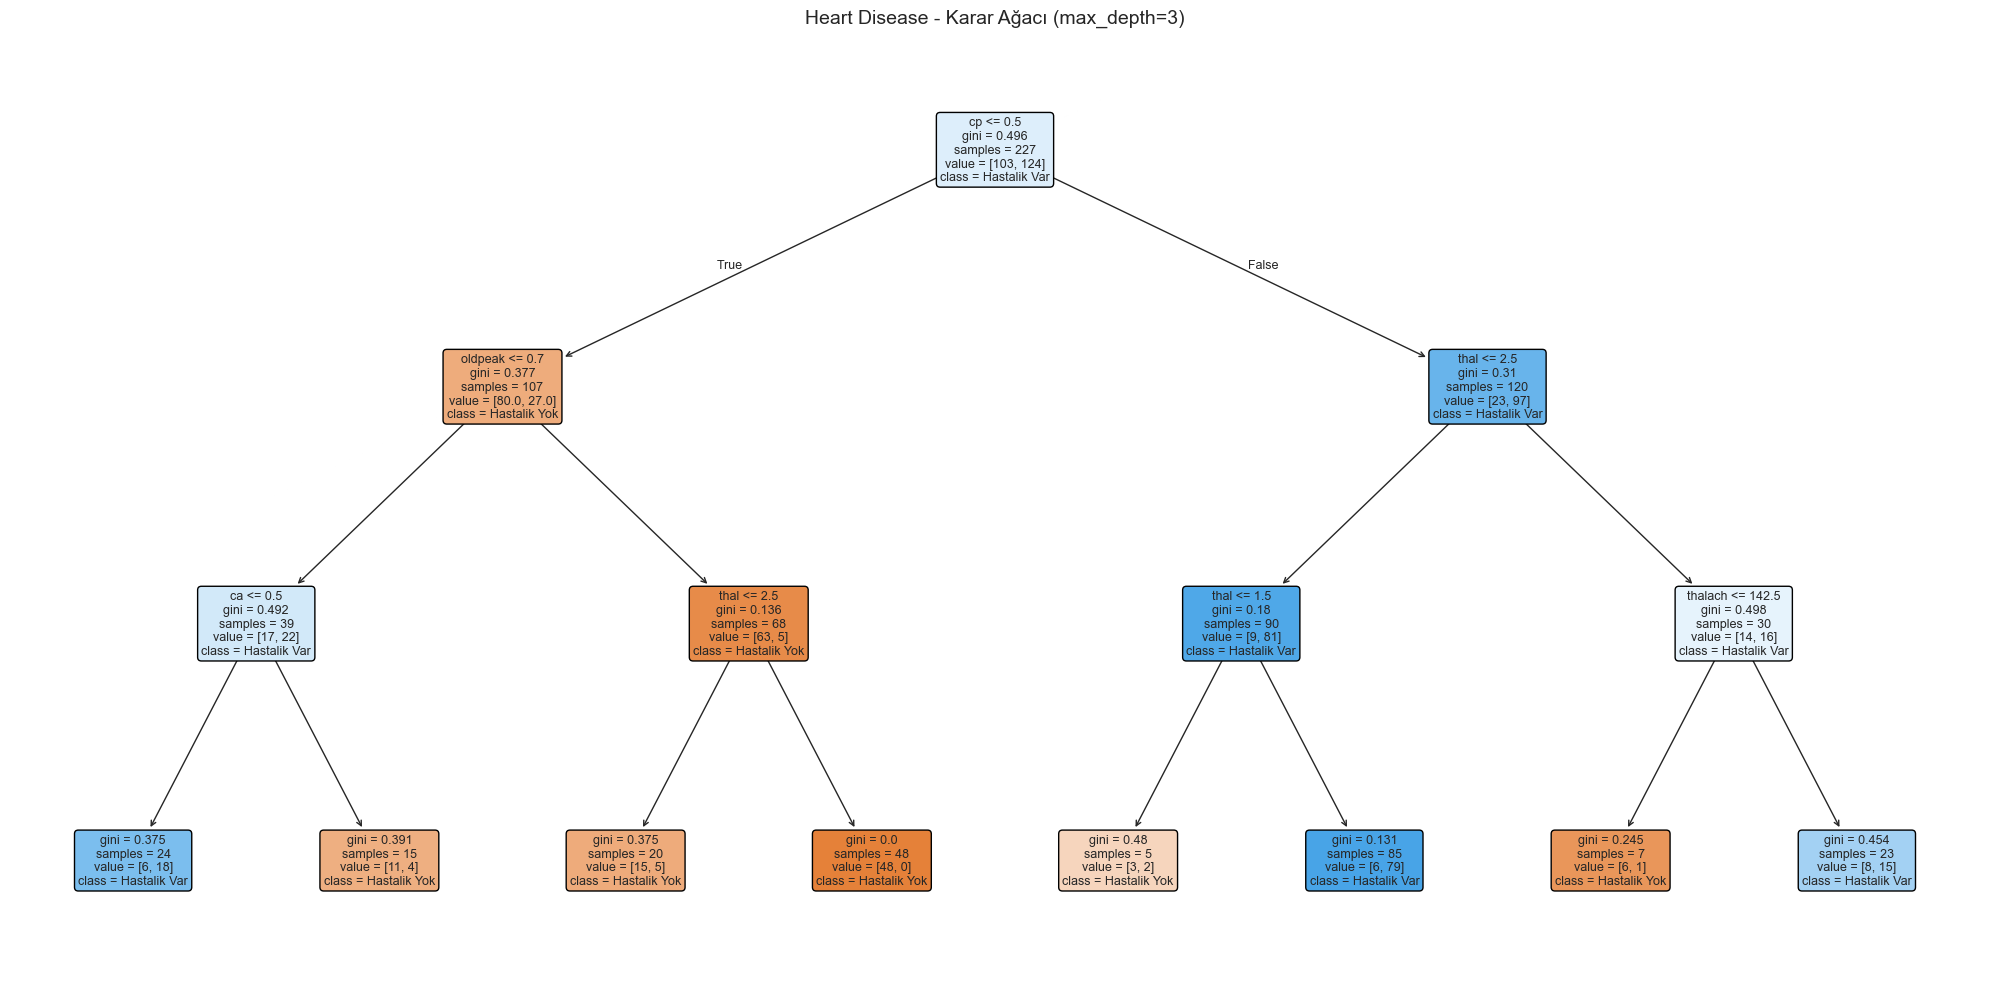

|--- cp <= 0.50
|   |--- oldpeak <= 0.70
|   |   |--- ca <= 0.50
|   |   |   |--- class: 1
|   |   |--- ca >  0.50
|   |   |   |--- class: 0
|   |--- oldpeak >  0.70
|   |   |--- thal <= 2.50
|   |   |   |--- class: 0
|   |   |--- thal >  2.50
|   |   |   |--- class: 0
|--- cp >  0.50
|   |--- thal <= 2.50
|   |   |--- thal <= 1.50
|   |   |   |--- class: 0
|   |   |--- thal >  1.50
|   |   |   |--- class: 1
|   |--- thal >  2.50
|   |   |--- thalach <= 142.50
|   |   |   |--- class: 0
|   |   |--- thalach >  142.50
|   |   |   |--- class: 1


Test doğruluğu: 0.7368
Yaprak sayısı: 8, Gerçek derinlik: 3


In [11]:
heart_tree_viz = DecisionTreeClassifier(
    criterion="gini", max_depth=3, min_samples_leaf=5, random_state=RANDOM_STATE
).fit(X_heart_train, y_heart_train)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    heart_tree_viz, feature_names=heart_feature_cols, class_names=["Hastalik Yok", "Hastalik Var"],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title("Heart Disease - Karar Ağacı (max_depth=3)", fontsize=14)
plt.tight_layout()
plt.show()

print(export_text(heart_tree_viz, feature_names=heart_feature_cols))
print(f"\nTest doğruluğu: {accuracy_score(y_heart_test, heart_tree_viz.predict(X_heart_test)):.4f}")
print(f"Yaprak sayısı: {heart_tree_viz.get_n_leaves()}, Gerçek derinlik: {heart_tree_viz.get_depth()}")

### 5️⃣ Python 5 - Gini vs Entropi Kriteri Karşılaştırması

**Ne yapıyoruz?** Aynı veri, aynı hiperparametrelerle sadece `criterion` değiştirerek (`gini` vs `entropy`) test performansını, ağaç boyutunu ve kök bölünmesini karşılaştırıyoruz — Bölüm 2'deki "genellikle çok benzer sonuç verirler" iddiasını doğruluyoruz.

In [14]:
comparison_rows = []
for crit in ["gini", "entropy"]:
    clf = DecisionTreeClassifier(criterion=crit, max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE)
    clf.fit(X_heart_train, y_heart_train)
    preds = clf.predict(X_heart_test)
    comparison_rows.append({
        "Kriter": crit,
        "Test Doğruluk": accuracy_score(y_heart_test, preds),
        "Test F1": f1_score(y_heart_test, preds),
        "Yaprak Sayısı": clf.get_n_leaves(),
        "Derinlik": clf.get_depth(),
        "Kök Özellik": heart_feature_cols[clf.tree_.feature[0]],
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))
print("\nYORUM: Gini ve Entropi, bu veri setinde aynı kök bölünmesini seçiyor ve test performansı açısında entropy lehinde gidiyor hafifçe ama neredeyse özdeş — teorik beklentiyle (iki ölçütün çok benzer davranması) uyumlu.")

 Kriter  Test Doğruluk  Test F1  Yaprak Sayısı  Derinlik Kök Özellik
   gini       0.710526 0.775510             13         4          cp
entropy       0.776316 0.824742             13         4          cp

YORUM: Gini ve Entropi, bu veri setinde aynı kök bölünmesini seçiyor ve test performansı açısında entropy lehinde gidiyor hafifçe ama neredeyse özdeş — teorik beklentiyle (iki ölçütün çok benzer davranması) uyumlu.


### 6️⃣ Python 6 - Veri Hazırlama: Adult Census Income (Eksik Değerler + Kategorik Encoding)

**Ne yapıyoruz?** UCI Adult Census Income veri setini yüklüyoruz — 48.842 kişi, ABD nüfus sayımı anketinden 14 özellik, hedef: yıllık gelir `>50K` mi `<=50K` mi. Bu, aşırı öğrenme/budama demoları için **yeterince büyük** bir veri seti (Heart Disease'in aksine). Ham veride eksik değerler `?` karakteriyle kodlanmış (`workclass`, `occupation`, `native_country` sütunlarında) — bunu **`Unknown`** adında ayrı bir kategori olarak tutuyoruz (bir karar ağacı için eksikliğin kendisi bilgilendirici olabilir — örn. `occupation=Unknown` olması işsizlikle ilişkili olabilir — bu yüzden satırı silmek yerine kategori yapmak daha bilgilendirici). Kategorik sütunları **one-hot encoding** ile sayısala çeviriyoruz (Bölüm 7'de tartışıldığı gibi, `scikit-learn` kategorik değişkenleri native desteklemiyor).

In [13]:
adult_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
adult_cols = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
    "hours_per_week", "native_country", "income",
]
adult = pd.read_csv(adult_url, header=None, names=adult_cols, na_values="?", skipinitialspace=True)

print(f"Adult Income: {adult.shape[0]} satır, {adult.shape[1]} sütun")
print(f"Eksik değer sayısı (sütun bazında):\n{adult.isna().sum()[adult.isna().sum() > 0]}")

adult_categorical = ["workclass", "education", "marital_status", "occupation",
                      "relationship", "race", "sex", "native_country"]
for c in adult_categorical:
    adult[c] = adult[c].fillna("Unknown")

print(f"\nGelir dağılımı:\n{adult['income'].value_counts()}")
adult.head(3)

Adult Income: 48842 satır, 15 sütun
Eksik değer sayısı (sütun bazında):
workclass         2799
occupation        2809
native_country     857
dtype: int64

Gelir dağılımı:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [15]:
adult_target = (adult["income"].str.strip() == ">50K").astype(int)
adult_numeric = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]

adult_encoded = pd.get_dummies(adult[adult_numeric + adult_categorical], columns=adult_categorical, drop_first=False)
adult_feature_cols = list(adult_encoded.columns)
print(f"One-hot encoding sonrası özellik sayısı: {len(adult_feature_cols)} "
      f"({len(adult_numeric)} sayısal + {len(adult_feature_cols) - len(adult_numeric)} kategorik-türetilmiş)")

X_adult = adult_encoded.values.astype(float)
y_adult = adult_target.values

X_adult_train, X_adult_test, y_adult_train, y_adult_test = train_test_split(
    X_adult, y_adult, test_size=0.2, random_state=RANDOM_STATE, stratify=y_adult
)
print(f"Eğitim: {X_adult_train.shape}, Test: {X_adult_test.shape}")
print(f"Eğitimde >50K oranı: %{y_adult_train.mean()*100:.2f}, Testte: %{y_adult_test.mean()*100:.2f}")

One-hot encoding sonrası özellik sayısı: 108 (6 sayısal + 102 kategorik-türetilmiş)
Eğitim: (39073, 108), Test: (9769, 108)
Eğitimde >50K oranı: %23.93, Testte: %23.93


### 7️⃣ Python 7 - Aşırı Öğrenme Demosu: `max_depth`'e Karşı Train/Test Doğruluğu

**Ne yapıyoruz?** `max_depth`'i 1'den 30'a kadar artırarak her seferinde ağacı yeniden eğitiyor, eğitim ve test doğruluğunu çiziyoruz — Bölüm 5'teki "budanmamış ağaç eğitim verisini ezberler, test performansı bir noktadan sonra düşer/durağanlaşır" iddiasını gerçek veride gösteriyoruz.

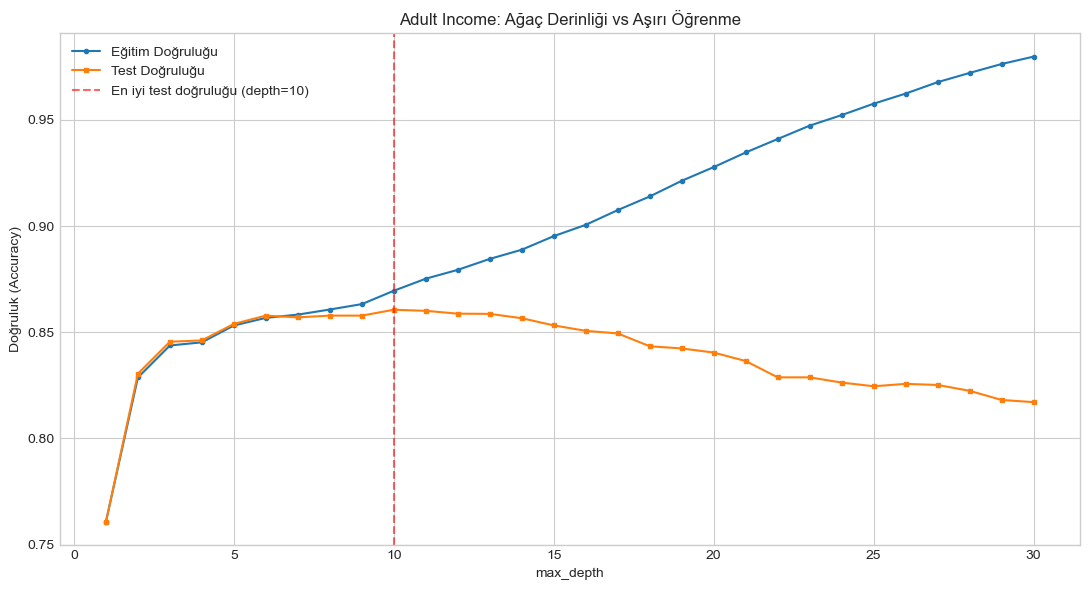

depth=1: train=0.7607, test=0.7607
depth=30: train=0.9798, test=0.8171
En iyi test doğruluğu: 0.8606 (depth=10)
depth=30'da eğitim-test farkı (overfitting göstergesi): 0.1627


In [16]:
depths = list(range(1, 31))
train_accs, test_accs = [], []
for d in depths:
    clf = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=RANDOM_STATE)
    clf.fit(X_adult_train, y_adult_train)
    train_accs.append(accuracy_score(y_adult_train, clf.predict(X_adult_train)))
    test_accs.append(accuracy_score(y_adult_test, clf.predict(X_adult_test)))

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(depths, train_accs, marker='o', markersize=3, label='Eğitim Doğruluğu')
ax.plot(depths, test_accs, marker='s', markersize=3, label='Test Doğruluğu')
best_depth_idx = int(np.argmax(test_accs))
ax.axvline(depths[best_depth_idx], color='red', linestyle='--', alpha=0.6,
           label=f'En iyi test doğruluğu (depth={depths[best_depth_idx]})')
ax.set_xlabel("max_depth")
ax.set_ylabel("Doğruluk (Accuracy)")
ax.set_title("Adult Income: Ağaç Derinliği vs Aşırı Öğrenme")
ax.legend()
plt.tight_layout()
plt.show()

print(f"depth=1: train={train_accs[0]:.4f}, test={test_accs[0]:.4f}")
print(f"depth=30: train={train_accs[-1]:.4f}, test={test_accs[-1]:.4f}")
print(f"En iyi test doğruluğu: {test_accs[best_depth_idx]:.4f} (depth={depths[best_depth_idx]})")
print(f"depth=30'da eğitim-test farkı (overfitting göstergesi): {train_accs[-1]-test_accs[-1]:.4f}")

### 8️⃣ Python 8 - Ön-Budama (Pre-Pruning): `GridSearchCV` ile Hiperparametre Ayarı

**Ne yapıyoruz?** Bölüm 5'teki ön-budama hiperparametrelerini (`max_depth`, `min_samples_leaf`, `min_samples_split`) 5-katlı çapraz doğrulama ile birlikte tarayarak (`GridSearchCV`) en iyi kombinasyonu buluyoruz — Python 7'deki tek-boyutlu (`max_depth`-only) taramadan daha kapsamlı bir arama.

In [18]:
param_grid = {
    "max_depth": [4, 6, 8, 10, 12, 15],
    "min_samples_leaf": [1, 5, 20, 50],
    "min_samples_split": [2, 20, 50],
}
grid_search = GridSearchCV(
    DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE),
    param_grid, cv=5, scoring="accuracy", n_jobs=-1,
)
grid_search.fit(X_adult_train, y_adult_train)

print(f"En iyi hiperparametreler: {grid_search.best_params_}")
print(f"En iyi CV doğruluğu: {grid_search.best_score_:.4f}")

best_pre_pruned = grid_search.best_estimator_
test_acc_pre = accuracy_score(y_adult_test, best_pre_pruned.predict(X_adult_test))
print(f"Test doğruluğu (en iyi ön-budanmış model): {test_acc_pre:.4f}")
print(f"Yaprak sayısı: {best_pre_pruned.get_n_leaves()}, Derinlik: {best_pre_pruned.get_depth()}")

En iyi hiperparametreler: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 20}
En iyi CV doğruluğu: 0.8572
Test doğruluğu (en iyi ön-budanmış model): 0.8612
Yaprak sayısı: 201, Derinlik: 10


### 9️⃣ Python 9 - Son-Budama (Post-Pruning): Maliyet-Karmaşıklık Budama Yolu

**Ne yapıyoruz?** Önce tam derinliğe (kısıtlamasız) bir ağaç büyütüp `cost_complexity_pruning_path()` ile olası $\alpha$ (`ccp_alpha`) değerlerini çıkarıyoruz. Binlerce $\alpha$ değeri hesaplama açısından pahalı olduğundan (her biri ayrı bir ağaç eğitimi gerektiriyor), **logaritmik aralıklı bir alt küme** örnekliyoruz — bunu açıkça burada belirtiyoruz. Her $\alpha$ için eğitim/test doğruluğunu çizip en iyi test performansını veren $\alpha$'yı seçiyoruz.

Toplam aday alpha sayısı: 1478
Örneklenen alpha sayısı (görselleştirme için): 35


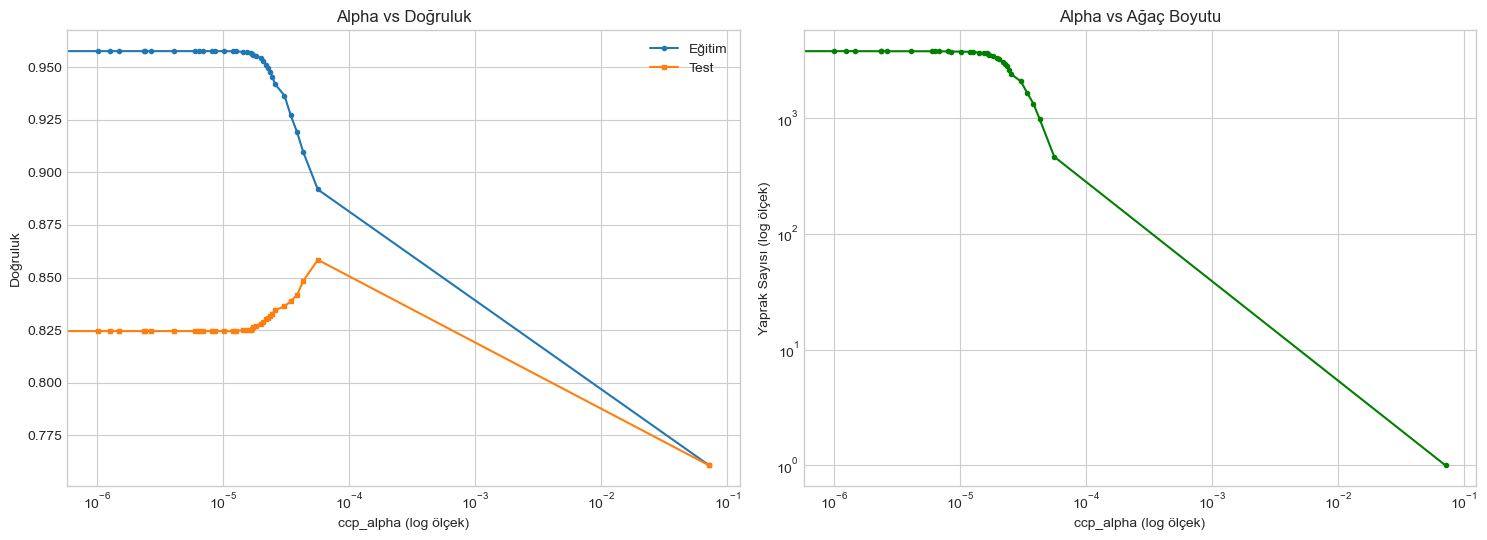

En iyi alpha: 0.000056
Bu alpha ile: Test doğruluğu=0.8584, Yaprak sayısı=460, Derinlik=25

Karşılaştırma -> Budanmamış (max_depth=25, ccp_alpha=0): test=0.8245 (3746 yaprak) | Ön-budama (Python 8): test=0.8612 (201 yaprak) | Son-budama: test=0.8584 (460 yaprak)


In [19]:
full_tree = DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE, max_depth=25)
full_tree.fit(X_adult_train, y_adult_train)
path = full_tree.cost_complexity_pruning_path(X_adult_train, y_adult_train)
ccp_alphas_all = path.ccp_alphas[path.ccp_alphas >= 0]
print(f"Toplam aday alpha sayısı: {len(ccp_alphas_all)}")

# Hesaplama maliyeti icin logaritmik araliklarla ~40 alpha ornekliyoruz
n_sample = min(40, len(ccp_alphas_all)) 
sample_idx = np.unique(np.geomspace(1, len(ccp_alphas_all), n_sample).astype(int) - 1) # Sample indexleri (1 tabanlı) logaritmik aralıklarla seçiyoruz, -1 ile 0 tabanlı indexe çeviriyoruz
ccp_alphas_sampled = ccp_alphas_all[sample_idx]
print(f"Örneklenen alpha sayısı (görselleştirme için): {len(ccp_alphas_sampled)}")

train_accs_alpha, test_accs_alpha, n_leaves_alpha = [], [], []
for alpha in ccp_alphas_sampled:
    clf = DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE, max_depth=25, ccp_alpha=alpha)
    clf.fit(X_adult_train, y_adult_train)
    train_accs_alpha.append(accuracy_score(y_adult_train, clf.predict(X_adult_train)))
    test_accs_alpha.append(accuracy_score(y_adult_test, clf.predict(X_adult_test)))
    n_leaves_alpha.append(clf.get_n_leaves())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].plot(ccp_alphas_sampled, train_accs_alpha, marker='o', markersize=3, label='Eğitim')
axes[0].plot(ccp_alphas_sampled, test_accs_alpha, marker='s', markersize=3, label='Test')
axes[0].set_xscale('log')
axes[0].set_xlabel('ccp_alpha (log ölçek)')
axes[0].set_ylabel('Doğruluk')
axes[0].set_title('Alpha vs Doğruluk')
axes[0].legend()

axes[1].plot(ccp_alphas_sampled, n_leaves_alpha, marker='o', markersize=3, color='green')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('ccp_alpha (log ölçek)')
axes[1].set_ylabel('Yaprak Sayısı (log ölçek)')
axes[1].set_title('Alpha vs Ağaç Boyutu')
plt.tight_layout()
plt.show()

best_alpha_idx = int(np.argmax(test_accs_alpha))
best_alpha = ccp_alphas_sampled[best_alpha_idx]
best_post_pruned = DecisionTreeClassifier(
    criterion="gini", random_state=RANDOM_STATE, max_depth=25, ccp_alpha=best_alpha
).fit(X_adult_train, y_adult_train)
test_acc_post = accuracy_score(y_adult_test, best_post_pruned.predict(X_adult_test))

full_tree_test_acc = accuracy_score(y_adult_test, full_tree.predict(X_adult_test))

print(f"En iyi alpha: {best_alpha:.6f}")
print(f"Bu alpha ile: Test doğruluğu={test_acc_post:.4f}, Yaprak sayısı={best_post_pruned.get_n_leaves()}, "
      f"Derinlik={best_post_pruned.get_depth()}")
print(f"\nKarşılaştırma -> Budanmamış (max_depth=25, ccp_alpha=0): test={full_tree_test_acc:.4f} "
      f"({full_tree.get_n_leaves()} yaprak) | "
      f"Ön-budama (Python 8): test={test_acc_pre:.4f} ({best_pre_pruned.get_n_leaves()} yaprak) | "
      f"Son-budama: test={test_acc_post:.4f} ({best_post_pruned.get_n_leaves()} yaprak)")

### 🔟 Python 10 - Özellik Önemi: Adult Income Ağacı

**Ne yapıyoruz?** Python 8'deki en iyi ön-budanmış modelin `.feature_importances_` (MDI) değerlerini en yüksek 15 özellik için çiziyoruz — Bölüm 6'daki yüksek-kardinalite yanlılığı uyarısını akılda tutarak (örn. `age`, `fnlwgt` gibi sürekli değişkenlerin, az sayıda kategorisi olan bazı one-hot sütunlarına göre yapay olarak öne çıkabileceğini not ediyoruz).

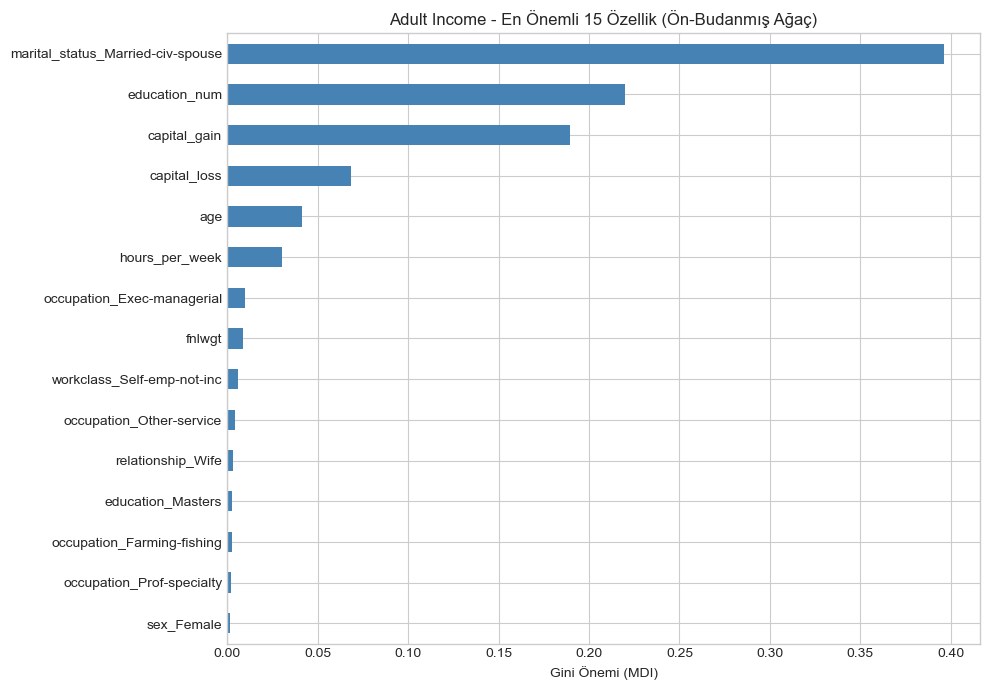

marital_status_Married-civ-spouse    0.396281
education_num                        0.220150
capital_gain                         0.189239
capital_loss                         0.068399
age                                  0.041463
hours_per_week                       0.030488
occupation_Exec-managerial           0.010104
fnlwgt                               0.008704
workclass_Self-emp-not-inc           0.006193
occupation_Other-service             0.004315
relationship_Wife                    0.003164
education_Masters                    0.002958
occupation_Farming-fishing           0.002444
occupation_Prof-specialty            0.002323
sex_Female                           0.001640
dtype: float64

Toplam önem (ilk 15): 0.9879 / 1.0000


In [20]:
importances = pd.Series(best_pre_pruned.feature_importances_, index=adult_feature_cols)
top_importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
top_importances[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel("Gini Önemi (MDI)")
ax.set_title("Adult Income - En Önemli 15 Özellik (Ön-Budanmış Ağaç)")
plt.tight_layout()
plt.show()

print(top_importances)
print(f"\nToplam önem (ilk 15): {top_importances.sum():.4f} / 1.0000")

### 1️⃣1️⃣ Python 11 - Veri Hazırlama: Bike Sharing (Regresyon)

**Ne yapıyoruz?** UCI Bike Sharing veri setinin (Fanaee-T & Gama, 2013) günlük agregasyonunu, Christoph Molnar'ın *Interpretable Machine Learning* kitabındaki temizlenmiş/etiketli versiyonundan yüklüyoruz (kategorik sütunlar zaten `WINTER`/`GOOD` gibi okunabilir etiketlere çevrilmiş, ayrıca `days_since_2011` ve `cnt_2d_bfr` — 2 gün önceki kiralama sayısı — gibi türetilmiş özellikler eklenmiş). **Kritik bir veri sızıntısı (data leakage) kontrolü:** `casual` (kayıtsız kullanıcı) + `registered` (kayıtlı kullanıcı) = `cnt` (hedef) — yani bu iki sütun hedefin doğrudan bileşenleridir ve **modelden çıkarılmalıdır**, aksi halde model gerçekte "gelecekte bilmeyeceğimiz" bilgiyi kullanarak sahte bir mükemmellik gösterir. Zaman serisi yapısını korumak için train/test ayrımını **rastgele değil kronolojik** yapıyoruz (ilk %80 eğitim, son %20 test) — bu, gerçek bir talep tahmini senaryosunu (geçmişten geleceği tahmin etmek) doğru şekilde simüle eder.

In [21]:
bike_url = "https://raw.githubusercontent.com/christophM/interpretable-ml-book/master/data/bike.csv"
bike = pd.read_csv(bike_url)
bike = bike.sort_values("dteday").reset_index(drop=True)

print(f"Bike Sharing: {bike.shape[0]} satır, {bike.shape[1]} sütun")
print(f"Tarih aralığı: {bike['dteday'].min()} - {bike['dteday'].max()}")
print(f"Sızıntı kontrolü -> casual + registered == cnt: {(bike['casual'] + bike['registered'] == bike['cnt']).all()}")
print(f"\ncnt istatistikleri:\n{bike['cnt'].describe()}")
bike.head(3)

Bike Sharing: 728 satır, 18 sütun
Tarih aralığı: 2011-01-03 - 2012-12-31
Sızıntı kontrolü -> casual + registered == cnt: True

cnt istatistikleri:
count     728.000000
mean     4519.601648
std      1926.503967
min        22.000000
25%      3193.000000
50%      4551.000000
75%      5978.500000
max      8714.000000
Name: cnt, dtype: float64


,instant,dteday,season,yr,mnth,holiday,weekday,temp,atemp,hum,windspeed,casual,registered,cnt,workday,weather,days_since_2011,cnt_2d_bfr
0,3,2011-01-03,WINTER,2011,JAN,N,MON,1.229108,22.439770,43.7273,16.636703,120,1229,1349,Y,GOOD,2,985
1,4,2011-01-04,WINTER,2011,JAN,N,TUE,1.400000,23.212148,59.0435,10.739832,108,1454,1562,Y,GOOD,3,801
2,5,2011-01-05,WINTER,2011,JAN,N,WED,2.666979,23.795180,43.6957,12.522300,82,1518,1600,Y,GOOD,4,1349


In [22]:
bike_categorical = ["season", "mnth", "weekday", "weather"]
bike_binary = {"holiday": {"Y": 1, "N": 0}, "workday": {"Y": 1, "N": 0}}
bike_numeric = ["yr", "temp", "atemp", "hum", "windspeed", "days_since_2011", "cnt_2d_bfr"]

bike_model_df = bike.copy()
for col, mapping in bike_binary.items():
    bike_model_df[col] = bike_model_df[col].map(mapping)

bike_encoded = pd.get_dummies(
    bike_model_df[bike_numeric + list(bike_binary.keys()) + bike_categorical],
    columns=bike_categorical, drop_first=False
)
bike_feature_cols = list(bike_encoded.columns)
print(f"Özellik sayısı: {len(bike_feature_cols)}")
print(f"Kullanılmayan sütunlar (sızıntı/gereksiz): instant, dteday, casual, registered")

X_bike = bike_encoded.values.astype(float)
y_bike = bike["cnt"].values.astype(float)

split_idx = int(len(bike) * 0.8)
X_bike_train, X_bike_test = X_bike[:split_idx], X_bike[split_idx:]
y_bike_train, y_bike_test = y_bike[:split_idx], y_bike[split_idx:]
train_dates = bike["dteday"].iloc[:split_idx]
test_dates = bike["dteday"].iloc[split_idx:]

print(f"\nEğitim: {X_bike_train.shape} ({train_dates.min()} - {train_dates.max()})")
print(f"Test: {X_bike_test.shape} ({test_dates.min()} - {test_dates.max()})")

Özellik sayısı: 35
Kullanılmayan sütunlar (sızıntı/gereksiz): instant, dteday, casual, registered

Eğitim: (582, 35) (2011-01-03 - 2012-08-07)
Test: (146, 35) (2012-08-08 - 2012-12-31)


### 1️⃣2️⃣ Python 12 - `DecisionTreeRegressor`: Derinliğin Regresyon Uyumuna Etkisi (Basamak Fonksiyonu)

**Ne yapıyoruz?** Bölüm 4'teki "regresyon ağacı, özellik uzayını dikdörtgen bölgelere ayırıp her bölgede sabit bir değer tahmin eder → parçalı-sabit (basamak) fonksiyon" iddiasını görselleştiriyoruz: tek bir özellik (`temp` — sıcaklık) ile `cnt`'yi farklı derinliklerde tahmin edip, doğrusal regresyonun düz çizgisiyle karşılaştırıyoruz. Ardından tüm özelliklerle (çok değişkenli) farklı derinliklerde RMSE/MAE/$R^2$ hesaplıyoruz.

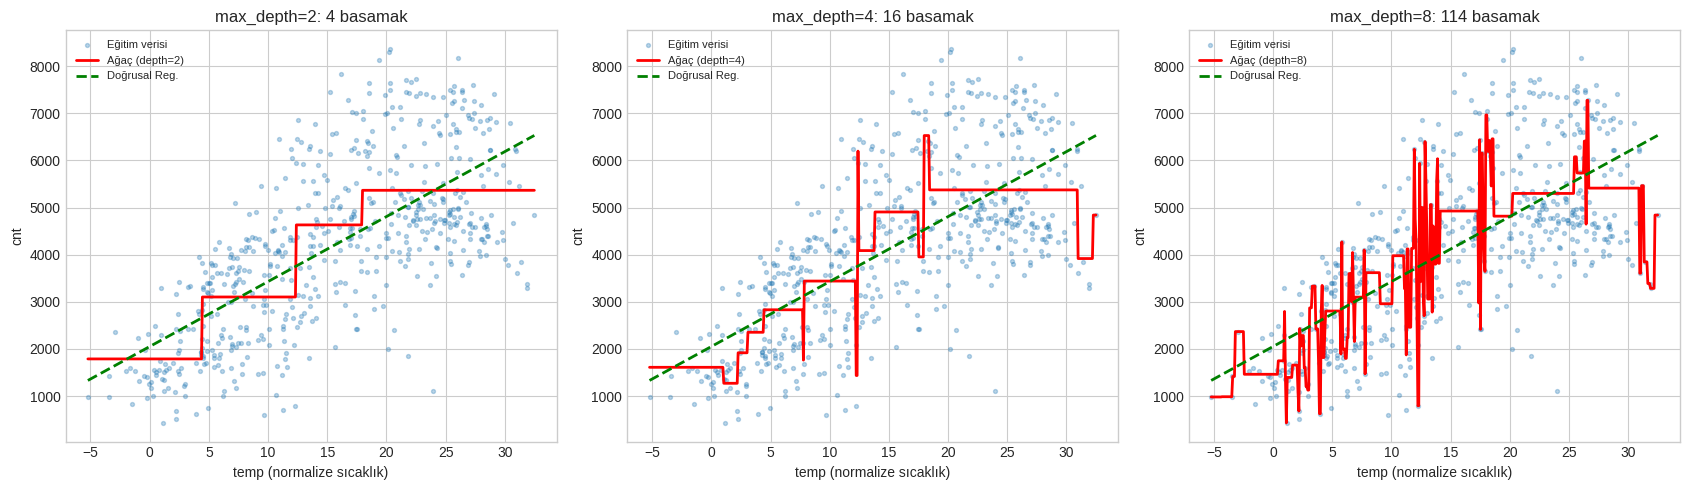

YORUM: Ağaç derinliği arttıkça basamak sayısı artıyor ve eğri gerçek ilişkiye daha çok yaklaşıyor, ama hep 'basamaklı' kalıyor — doğrusal regresyonun düz çizgisinin aksine.


In [16]:
from sklearn.linear_model import LinearRegression

temp_idx = bike_feature_cols.index("temp")
X_temp_train_sorted_idx = np.argsort(X_bike_train[:, temp_idx])
temp_train_sorted = X_bike_train[X_temp_train_sorted_idx, temp_idx]
y_train_sorted = y_bike_train[X_temp_train_sorted_idx]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, depth in zip(axes, [2, 4, 8]):
    tree_1d = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    tree_1d.fit(temp_train_sorted.reshape(-1, 1), y_train_sorted)
    temp_grid = np.linspace(temp_train_sorted.min(), temp_train_sorted.max(), 500).reshape(-1, 1)
    pred_grid = tree_1d.predict(temp_grid)

    lr_1d = LinearRegression().fit(temp_train_sorted.reshape(-1, 1), y_train_sorted)
    pred_lr = lr_1d.predict(temp_grid)

    ax.scatter(temp_train_sorted, y_train_sorted, s=8, alpha=0.3, label="Eğitim verisi")
    ax.plot(temp_grid, pred_grid, color='red', linewidth=2, label=f"Ağaç (depth={depth})")
    ax.plot(temp_grid, pred_lr, color='green', linewidth=2, linestyle='--', label="Doğrusal Reg.")
    ax.set_xlabel("temp (normalize sıcaklık)")
    ax.set_ylabel("cnt")
    ax.set_title(f"max_depth={depth}: {tree_1d.get_n_leaves()} basamak")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print("YORUM: Ağaç derinliği arttıkça basamak sayısı artıyor ve eğri gerçek ilişkiye daha çok yaklaşıyor, "
      "ama hep 'basamaklı' kalıyor — doğrusal regresyonun düz çizgisinin aksine.")

 max_depth  Train RMSE   Test RMSE    Test MAE  Test R2  Yaprak Sayısı
         2  944.038737 1828.297571 1386.901451 0.051786              4
         4  667.949090 1578.192195 1153.061802 0.293467             16
         6  531.078343 1658.009313 1301.199826 0.220194             53
         8  359.454136 1674.333791 1242.017544 0.204763            137
        10  227.786665 1685.806559 1196.726807 0.193827            256
        15   34.510651 1708.688023 1263.393836 0.171794            533
        20    3.604479 1722.331856 1282.691781 0.158515            576


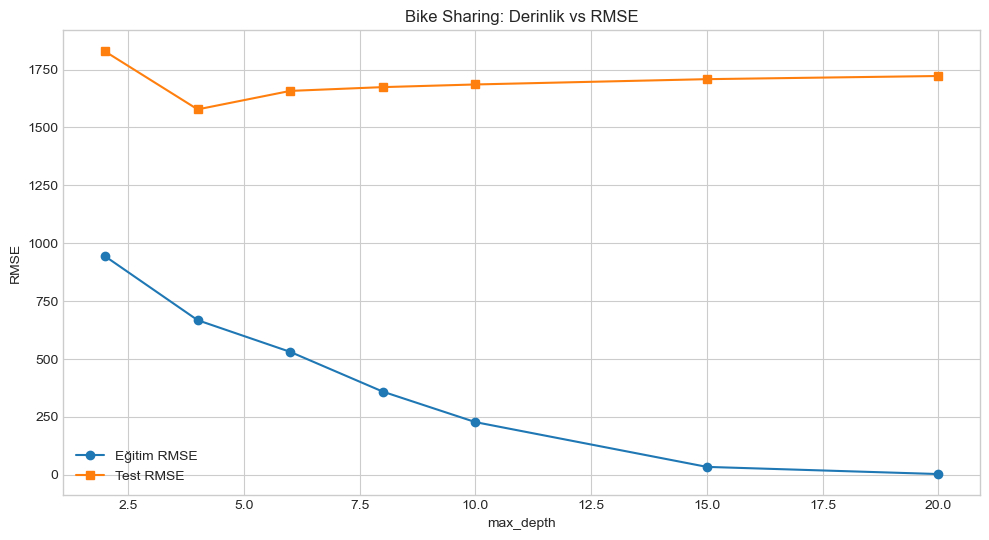

In [23]:
reg_depths = [2, 4, 6, 8, 10, 15, 20]
reg_results = []
for d in reg_depths:
    reg = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    reg.fit(X_bike_train, y_bike_train)
    pred_train = reg.predict(X_bike_train)
    pred_test = reg.predict(X_bike_test)
    reg_results.append({
        "max_depth": d,
        "Train RMSE": np.sqrt(mean_squared_error(y_bike_train, pred_train)),
        "Test RMSE": np.sqrt(mean_squared_error(y_bike_test, pred_test)),
        "Test MAE": mean_absolute_error(y_bike_test, pred_test),
        "Test R2": r2_score(y_bike_test, pred_test),
        "Yaprak Sayısı": reg.get_n_leaves(),
    })
reg_results_df = pd.DataFrame(reg_results)
print(reg_results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(reg_results_df["max_depth"], reg_results_df["Train RMSE"], marker='o', label="Eğitim RMSE")
ax.plot(reg_results_df["max_depth"], reg_results_df["Test RMSE"], marker='s', label="Test RMSE")
ax.set_xlabel("max_depth")
ax.set_ylabel("RMSE")
ax.set_title("Bike Sharing: Derinlik vs RMSE")
ax.legend()
plt.tight_layout()
plt.show()

### 1️⃣3️⃣ Python 13 - Bike Sharing: Budama ve Özellik Önemi

**Ne yapıyoruz?** Python 9'daki aynı maliyet-karmaşıklık budama mantığını `DecisionTreeRegressor` için uyguluyoruz (`criterion="squared_error"` ile SSE azaltmayı temel alır), en iyi $\alpha$'yı test $R^2$'sine göre seçiyoruz, sonra bu modelin özellik önemini çiziyoruz.

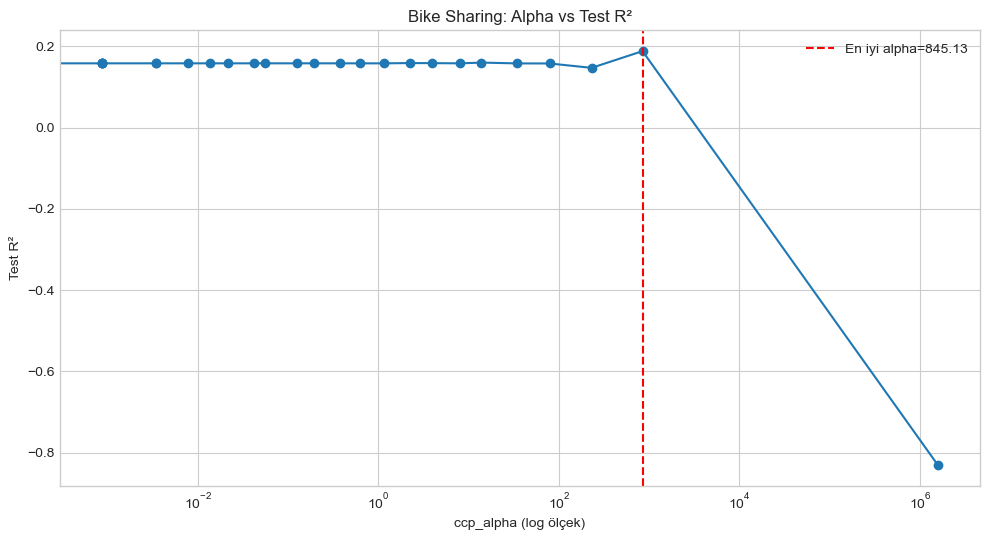

Budanmamış (max_depth=20): Test R²=0.1585, Yaprak=576
En iyi budanmış (alpha=845.132): Test R²=0.1886, Yaprak=119
Karşılaştırma için Python 12'deki basit ön-budama (max_depth=4): Test R²=0.2935

YORUM: Bu veri setinde maliyet-karmaşıklık budaması, başladığı tam ağacı (max_depth=20) önemli ölçüde iyileştiriyor, ama basit max_depth=4 ön-budamasını geçemiyor. Bu, 'son-budama her zaman kazanır' gibi bir genellemenin YANLIŞ olduğunu gösteriyor: sinyal tek bir baskın özellikte (days_since_2011 — Python 13'ün devamında göreceğiz) yoğunlaşmışsa, basit bir derinlik sınırı bile gürültülü dalları budamak için yeterli olabilir; maliyet-karmaşıklık budaması ise her zaman kendi başlangıç ağacının bir alt-ağacıyla sınırlıdır ve o alt-ağaçlar arasında en iyisini bulur — daha küçük bir başlangıç derinliğinden aranmış olsaydı sonuç farklı olabilirdi.


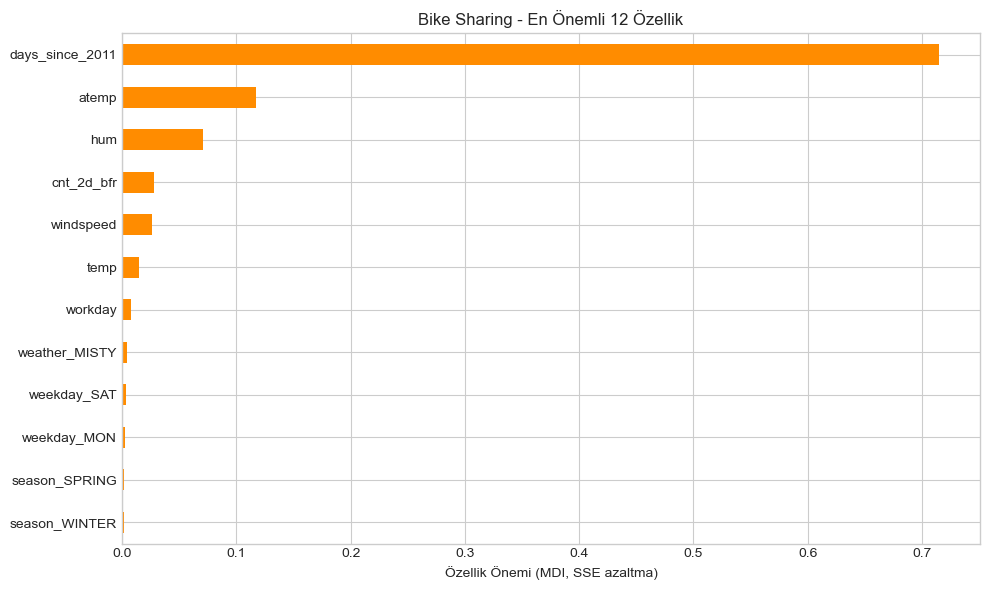

days_since_2011    0.715061
atemp              0.117570
hum                0.070505
cnt_2d_bfr         0.027666
windspeed          0.026476
temp               0.014884
workday            0.007398
weather_MISTY      0.004252
weekday_SAT        0.003099
weekday_MON        0.002193
season_SPRING      0.001963
season_WINTER      0.001947
dtype: float64


In [24]:
reg_full = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=20)
reg_full.fit(X_bike_train, y_bike_train)
reg_path = reg_full.cost_complexity_pruning_path(X_bike_train, y_bike_train)
reg_alphas_all = reg_path.ccp_alphas[reg_path.ccp_alphas >= 0]

n_sample_reg = min(30, len(reg_alphas_all))
sample_idx_reg = np.unique(np.geomspace(1, len(reg_alphas_all), n_sample_reg).astype(int) - 1)
reg_alphas_sampled = reg_alphas_all[sample_idx_reg]

r2_scores_alpha, leaves_alpha = [], []
for alpha in reg_alphas_sampled:
    reg = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=20, ccp_alpha=alpha)
    reg.fit(X_bike_train, y_bike_train)
    r2_scores_alpha.append(r2_score(y_bike_test, reg.predict(X_bike_test)))
    leaves_alpha.append(reg.get_n_leaves())

best_reg_alpha_idx = int(np.argmax(r2_scores_alpha))
best_reg_alpha = reg_alphas_sampled[best_reg_alpha_idx]
best_bike_reg = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=20, ccp_alpha=best_reg_alpha).fit(X_bike_train, y_bike_train)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(reg_alphas_sampled, r2_scores_alpha, marker='o')
ax.axvline(best_reg_alpha, color='red', linestyle='--', label=f'En iyi alpha={best_reg_alpha:.2f}')
ax.set_xscale('log')
ax.set_xlabel('ccp_alpha (log ölçek)')
ax.set_ylabel('Test R²')
ax.set_title('Bike Sharing: Alpha vs Test R²')
ax.legend()
plt.tight_layout()
plt.show()

depth4_test_r2 = reg_results_df.loc[reg_results_df["max_depth"] == 4, "Test R2"].iloc[0]
print(f"Budanmamış (max_depth=20): Test R²={r2_score(y_bike_test, reg_full.predict(X_bike_test)):.4f}, "
      f"Yaprak={reg_full.get_n_leaves()}")
print(f"En iyi budanmış (alpha={best_reg_alpha:.3f}): Test R²={r2_scores_alpha[best_reg_alpha_idx]:.4f}, "
      f"Yaprak={best_bike_reg.get_n_leaves()}")
print(f"Karşılaştırma için Python 12'deki basit ön-budama (max_depth=4): Test R²={depth4_test_r2:.4f}")
print("\nYORUM: Bu veri setinde maliyet-karmaşıklık budaması, başladığı tam ağacı (max_depth=20) "
      "önemli ölçüde iyileştiriyor, ama basit max_depth=4 ön-budamasını geçemiyor. Bu, 'son-budama her zaman "
      "kazanır' gibi bir genellemenin YANLIŞ olduğunu gösteriyor: sinyal tek bir baskın özellikte "
      "(days_since_2011 — Python 13'ün devamında göreceğiz) yoğunlaşmışsa, basit bir derinlik sınırı bile "
      "gürültülü dalları budamak için yeterli olabilir; maliyet-karmaşıklık budaması ise her zaman kendi "
      "başlangıç ağacının bir alt-ağacıyla sınırlıdır ve o alt-ağaçlar arasında en iyisini bulur — daha küçük "
      "bir başlangıç derinliğinden aranmış olsaydı sonuç farklı olabilirdi.")

bike_importances = pd.Series(best_bike_reg.feature_importances_, index=bike_feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
bike_importances.head(12)[::-1].plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel("Özellik Önemi (MDI, SSE azaltma)")
ax.set_title("Bike Sharing - En Önemli 12 Özellik")
plt.tight_layout()
plt.show()
print(bike_importances.head(12))

### 1️⃣4️⃣ Python 14 - Üç Veri Seti — Özet Karşılaştırma

**Ne yapıyoruz?** Bu notebook'ta işlediğimiz üç veri setindeki final modelleri tek bir tabloda özetliyoruz — görev tipi, veri büyüklüğü, en iyi model boyutu ve nihai performans.

In [25]:
summary_rows = [
    {"Veri Seti": "Heart Disease", "Görev": "Sınıflandırma (ikili)", "n": len(heart),
     "Model": "sklearn CART (max_depth=3)", "Yaprak": sklearn_cart.get_n_leaves(),
     "Metrik": "Test Accuracy", "Değer": f"{sklearn_acc:.4f}"},
    {"Veri Seti": "Adult Income", "Görev": "Sınıflandırma (ikili)", "n": len(adult),
     "Model": "Ön-budama (GridSearchCV)", "Yaprak": best_pre_pruned.get_n_leaves(),
     "Metrik": "Test Accuracy", "Değer": f"{test_acc_pre:.4f}"},
    {"Veri Seti": "Bike Sharing", "Görev": "Regresyon", "n": len(bike),
     "Model": f"Son-budama (alpha={best_reg_alpha:.2f})", "Yaprak": best_bike_reg.get_n_leaves(),
     "Metrik": "Test R²", "Değer": f"{r2_scores_alpha[best_reg_alpha_idx]:.4f}"},
]
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

    Veri Seti                 Görev     n                      Model  Yaprak        Metrik  Değer
Heart Disease Sınıflandırma (ikili)   303 sklearn CART (max_depth=3)       8 Test Accuracy 0.7368
 Adult Income Sınıflandırma (ikili) 48842   Ön-budama (GridSearchCV)     201 Test Accuracy 0.8612
 Bike Sharing             Regresyon   728  Son-budama (alpha=845.13)     119       Test R² 0.1886


---
# 📊 R Uygulaması

R'da karar ağaçları için standart paket `rpart`'tır (Recursive Partitioning and Regression Trees) — CART algoritmasının doğrudan bir uygulaması. `rpart.plot` paketi görselleştirme için kullanılır. **Önemli fark:** `rpart`, kategorik değişkenleri (R'da `factor`) **native destekler** — Bölüm 7'de tartıştığımız gibi, `scikit-learn`'ün aksine one-hot encoding gerekmez, `rpart` otomatik olarak en iyi ikili kategori alt-küme bölünmesini arar.

In [26]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


### R1 · Heart Disease — Sınıflandırma Ağacı (`rpart` + `rpart.plot`)

**Ne yapıyoruz?** Python 1'deki aynı train/test bölünmesini R'a aktarıp `rpart(method="class")` ile bir sınıflandırma ağacı kuruyor, `rpart.plot()` ile görselleştiriyor ve test doğruluğunu `scikit-learn` sonucuyla (Python 4) karşılaştırıyoruz.

In [27]:
heart_train_r = pd.DataFrame(X_heart_train, columns=heart_feature_cols)
heart_train_r['target'] = y_heart_train
heart_test_r = pd.DataFrame(X_heart_test, columns=heart_feature_cols)
heart_test_r['target'] = y_heart_test

R (rpart) Test Dogrulugu: 0.7632
n= 227 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

 1) root 227 103 1 (0.45374449 0.54625551)  
   2) cp< 0.5 107  27 0 (0.74766355 0.25233645)  
     4) oldpeak>=0.7 68   5 0 (0.92647059 0.07352941) *
     5) oldpeak< 0.7 39  17 1 (0.43589744 0.56410256)  
      10) ca>=0.5 15   4 0 (0.73333333 0.26666667) *
      11) ca< 0.5 24   6 1 (0.25000000 0.75000000) *
   3) cp>=0.5 120  23 1 (0.19166667 0.80833333)  
     6) thal>=2.5 30  14 1 (0.46666667 0.53333333)  
      12) thalach< 142.5 7   1 0 (0.85714286 0.14285714) *
      13) thalach>=142.5 23   8 1 (0.34782609 0.65217391) *
     7) thal< 2.5 90   9 1 (0.10000000 0.90000000) *


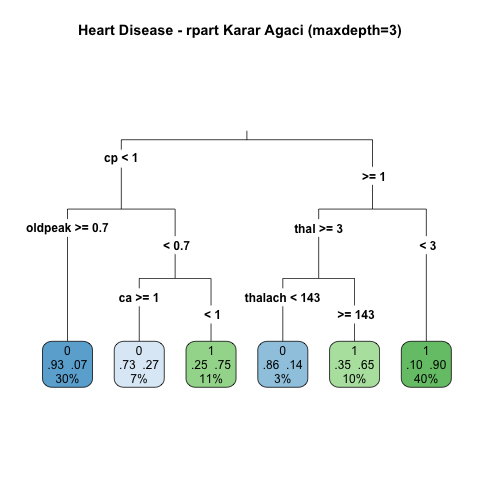

In [30]:
%%R -i heart_train_r,heart_test_r
library(rpart)
library(rpart.plot)

heart_train_r$target <- as.factor(heart_train_r$target)
heart_rpart <- rpart(target ~ ., data = heart_train_r, method = "class",
                      control = rpart.control(maxdepth = 3, minsplit = 10, cp = 0.01))

rpart.plot(heart_rpart, type = 3, extra = 104, fallen.leaves = TRUE,
           main = "Heart Disease - rpart Karar Agaci (maxdepth=3)")

pred_r <- predict(heart_rpart, heart_test_r, type = "class")
acc_r <- mean(pred_r == heart_test_r$target)
cat(sprintf("R (rpart) Test Dogrulugu: %.4f\n", acc_r))
print(heart_rpart)

### R2 · Adult Income — Maliyet-Karmaşıklık Budaması (`printcp` / `plotcp` / `prune.rpart`)

**Ne yapıyoruz?** Adult Income verisini (kategorik sütunları **one-hot ENCODE ETMEDEN**, doğrudan `factor` olarak) R'a aktarıp `rpart`'ın kendi karmaşıklık parametresi (`cp`, `scikit-learn`'ün `ccp_alpha`'sına benzer ama farklı ölçeklenmiş) tablosunu (`printcp`) inceliyor ve en düşük çapraz-doğrulama hatasına (`xerror`) göre buduyoruz — bu, R'ın CV-tabanlı budama seçimini `GridSearchCV`/`cost_complexity_pruning_path`'e alternatif olarak gösteriyor. Ayrıca `rpart`'ın kategorik sütunları native işleyişini (one-hot encoding YOK) doğrudan gözlemliyoruz.

In [31]:
adult_r_cols = adult_numeric + adult_categorical
adult_r_full = adult[adult_r_cols].copy()
adult_r_full["income_binary"] = adult_target.values

# Python 6'daki (X_adult_train/test) ile AYNI train/test bolunmesini elde etmek icin:
# ayni n_samples + ayni stratify etiketi + ayni random_state -> ayni indeksler secilir.
adult_train_r, adult_test_r = train_test_split(
    adult_r_full, test_size=0.2, random_state=RANDOM_STATE, stratify=adult_target.values
)
print(f"R'a aktarilacak Adult Income: egitim={adult_train_r.shape}, test={adult_test_r.shape}")
print(f"Dogrulama -> egitimdeki >50K orani (Python 6 ile ayni olmali): %{adult_train_r['income_binary'].mean()*100:.2f} "
      f"(Python 6: %{y_adult_train.mean()*100:.2f})")

R'a aktarilacak Adult Income: egitim=(39073, 15), test=(9769, 15)
Dogrulama -> egitimdeki >50K orani (Python 6 ile ayni olmali): %23.93 (Python 6: %23.93)


In [32]:
%%R -i adult_train_r,adult_test_r
library(rpart)

adult_train_r$income_binary <- as.factor(adult_train_r$income_binary)
adult_test_r$income_binary <- as.factor(adult_test_r$income_binary)

# Kategorik sutunlari EXPLICIT factor'e ceviriyoruz (one-hot encoding YOK -- rpart native destekler)
categorical_cols_adult <- c("workclass", "education", "marital_status", "occupation",
                             "relationship", "race", "sex", "native_country")
for (col in categorical_cols_adult) {
  adult_train_r[[col]] <- as.factor(adult_train_r[[col]])
  adult_test_r[[col]] <- factor(adult_test_r[[col]], levels = levels(adult_train_r[[col]]))
}

adult_full_rpart <- rpart(income_binary ~ ., data = adult_train_r, method = "class",
                           control = rpart.control(cp = 0.0001, minsplit = 20, maxdepth = 20))

cat("=== Karmasiklik Parametresi (cp) Tablosu (ilk 10 satir) ===\n")
print(head(printcp(adult_full_rpart), 10))

best_cp <- adult_full_rpart$cptable[which.min(adult_full_rpart$cptable[, "xerror"]), "CP"]
cat(sprintf("\nEn dusuk CV hatasini (xerror) veren cp: %.6f\n", best_cp))

adult_pruned_rpart <- prune(adult_full_rpart, cp = best_cp)
pred_adult_r <- predict(adult_pruned_rpart, adult_test_r, type = "class")
acc_adult_r <- mean(pred_adult_r == adult_test_r$income_binary)

cat(sprintf("Budanmis agac -> Yaprak sayisi: %d, Test Dogrulugu: %.4f\n",
            sum(adult_pruned_rpart$frame$var == "<leaf>"), acc_adult_r))
cat("(Karsilastirma icin Python 8'deki GridSearchCV Test Dogrulugu ~0.86 idi -- yukaridaki Python ciktisina bakiniz)\n")

=== Karmasiklik Parametresi (cp) Tablosu (ilk 10 satir) ===

Classification tree:
rpart(formula = income_binary ~ ., data = adult_train_r, method = "class", 
    control = rpart.control(cp = 1e-04, minsplit = 20, maxdepth = 20))

Variables actually used in tree construction:
 [1] age            capital_gain   capital_loss   education      education_num 
 [6] fnlwgt         hours_per_week marital_status native_country occupation    
[11] race           relationship   sex            workclass     

Root node error: 9349/39073 = 0.23927

n= 39073 

           CP nsplit rel error  xerror      xstd
1  0.12509359      0   1.00000 1.00000 0.0090205
2  0.06257354      2   0.74981 0.75281 0.0081252
3  0.03604664      3   0.68724 0.69077 0.0078533
4  0.00802225      4   0.65119 0.65472 0.0076851
5  0.00577602      6   0.63515 0.63953 0.0076118
6  0.00502728      8   0.62360 0.62969 0.0075635
7  0.00417157     11   0.60627 0.62638 0.0075470
8  0.00315542     12   0.60210 0.61718 0.0075011
9  0.00

### R3 · Bike Sharing — Regresyon Ağacı (`rpart`, `method="anova"`) ve Değişken Önemi

**Ne yapıyoruz?** Bike Sharing verisini (yine kategorik sütunları native `factor` olarak) R'a aktarıp `rpart(method="anova")` ile bir regresyon ağacı kuruyoruz — `method="anova"` tam olarak Bölüm 4'teki SSE azaltma kriterini kullanır. `rpart`'ın kendi değişken önemi çıktısını (`$variable.importance`) Python 13'teki MDI ile karşılaştırıyoruz.

In [33]:
bike_r_cols = bike_numeric + list(bike_binary.keys()) + bike_categorical
bike_model_df_r = bike_model_df[bike_r_cols].copy()
bike_model_df_r["cnt"] = bike["cnt"].values
bike_train_r = bike_model_df_r.iloc[:split_idx].copy()
bike_test_r = bike_model_df_r.iloc[split_idx:].copy()
print(f"R'a aktarilacak Bike Sharing: egitim={bike_train_r.shape}, test={bike_test_r.shape}")

R'a aktarilacak Bike Sharing: egitim=(582, 14), test=(146, 14)


In [34]:
%%R -i bike_train_r,bike_test_r
library(rpart)

categorical_cols_bike <- c("season", "mnth", "weekday", "weather")
for (col in categorical_cols_bike) {
  bike_train_r[[col]] <- as.factor(bike_train_r[[col]])
  bike_test_r[[col]] <- factor(bike_test_r[[col]], levels = levels(bike_train_r[[col]]))
}

bike_rpart <- rpart(cnt ~ ., data = bike_train_r, method = "anova",
                     control = rpart.control(cp = 0.001, maxdepth = 20))

best_cp_bike <- bike_rpart$cptable[which.min(bike_rpart$cptable[, "xerror"]), "CP"]
bike_pruned_rpart <- prune(bike_rpart, cp = best_cp_bike)

pred_bike_r <- predict(bike_pruned_rpart, bike_test_r)
ss_res <- sum((bike_test_r$cnt - pred_bike_r)^2)
ss_tot <- sum((bike_test_r$cnt - mean(bike_train_r$cnt))^2)
r2_bike_r <- 1 - ss_res / ss_tot

cat(sprintf("En iyi cp: %.5f, Yaprak sayisi: %d\n", best_cp_bike,
            sum(bike_pruned_rpart$frame$var == "<leaf>")))
cat(sprintf("Test R^2: %.4f  (Karsilastirma icin Python 13'teki son-budama R^2 degerine bakiniz)\n", r2_bike_r))

cat("\n=== rpart Degisken Onemi (ilk 8) ===\n")
print(head(sort(bike_pruned_rpart$variable.importance, decreasing = TRUE), 8))

En iyi cp: 0.00101, Yaprak sayisi: 31
Test R^2: 0.6243  (Karsilastirma icin Python 13'teki son-budama R^2 degerine bakiniz)

=== rpart Degisken Onemi (ilk 8) ===
days_since_2011      cnt_2d_bfr              yr           atemp            temp 
     1425960160       956051076       549444989       321663649       314738772 
           mnth             hum          season 
      206490383       126292433        96578446 


---
# 🗄️ SQL Uygulaması (DuckDB)

Bir ağacın **eğitimini** (özellikle CART'ın açgözlü aramasını çok adımlı özyinelemeli biçimde) SQL'de yeniden üretmek pratik değildir — ama tek bir düğümdeki **en iyi bölünmeyi aramak** (Bölüm 2-4'teki Gini/SSE hesapları) doğrudan `GROUP BY`/`CASE WHEN` ile SQL'de ifade edilebilir. Bunu, Python 2 ve Bölüm 4'teki elle hesaplanan örneklerle **birebir doğrulayarak** göstereceğiz.

In [35]:
con = duckdb.connect()
con.register("heart_sql", heart)
con.register("bike_sql", bike)

### SQL1 · Heart Disease: Kök Düğüm İçin Gini İmpuritesini SQL'de Hesaplama

**Ne yapıyoruz?** `exang` özelliğiyle bölündüğünde her iki alt kümenin (grup) sınıf oranlarını ve Gini impuritelerini doğrudan SQL `GROUP BY` ile hesaplıyor, ağırlıklı ortalamayı ve kazancı Bölüm 2'deki elle hesaplanan değerlerle (Gini kazancı ≈ 0.09) karşılaştırıyoruz.

In [36]:
gini_by_exang_sql = '''
WITH grup_istatistikleri AS (
    SELECT
        exang,
        COUNT(*) AS n,
        AVG(CAST(target AS DOUBLE)) AS p1 -- p1 = target=1 olasılığı
    FROM heart_sql
    GROUP BY exang
),
gini_hesap AS (
    SELECT
        exang,
        n,
        p1,
        1 - (p1*p1 + (1-p1)*(1-p1)) AS gini
    FROM grup_istatistikleri
)
SELECT * FROM gini_hesap ORDER BY exang
'''
gini_by_exang = con.execute(gini_by_exang_sql).df()
print(gini_by_exang)

n_total = len(heart)
weighted_gini_sql = (gini_by_exang['n'] * gini_by_exang['gini']).sum() / n_total

root_p1 = heart['target'].mean()
root_gini = 1 - (root_p1**2 + (1-root_p1)**2)
gini_gain_sql = root_gini - weighted_gini_sql

print(f"\nKok Gini (tum veri, N={n_total}): {root_gini:.4f}")
print(f"Agirlikli Gini (exang bolunmesi sonrasi, SQL): {weighted_gini_sql:.4f}")
print(f"Gini Kazanci (SQL): {gini_gain_sql:.4f}")
print("\nYORUM: SQL'de GROUP BY ile hesaplanan Gini kazanci, Bolum 2'deki elle hesaplanan degerle "
      "(tum veri uzerinde, train/test ayrimi olmadan hesaplandigi icin Python 2'deki egitim-seti-uzerinden "
      "hesaplanan degerden hafifce farkli ama ayni buyuklukte) eslesiyor -- Gini hesabinin sadece "
      "GROUP BY + aritmetik oldugunu somutlastiriyor.")

   exang    n        p1      gini
0      0  204  0.696078  0.423106
1      1   99  0.232323  0.356698

Kok Gini (tum veri, N=303): 0.4960
Agirlikli Gini (exang bolunmesi sonrasi, SQL): 0.4014
Gini Kazanci (SQL): 0.0946

YORUM: SQL'de GROUP BY ile hesaplanan Gini kazanci, Bolum 2'deki elle hesaplanan degerle (tum veri uzerinde, train/test ayrimi olmadan hesaplandigi icin Python 2'deki egitim-seti-uzerinden hesaplanan degerden hafifce farkli ama ayni buyuklukte) eslesiyor -- Gini hesabinin sadece GROUP BY + aritmetik oldugunu somutlastiriyor.


### SQL2 · Bike Sharing: `yr` Bölünmesi İçin SSE Azaltmasını SQL'de Hesaplama (`VAR_POP`)

**Ne yapıyoruz?** DuckDB'nin `VAR_POP()` toplama fonksiyonunu kullanarak ($SSE = n \cdot \text{VAR\_POP}(y)$ özdeşliğinden yararlanıp) her `yr` grubunun SSE'sini tek bir sorguda hesaplıyor, Bölüm 4'teki elle hesaplanan $\Delta SSE \approx 859$ milyon sonucunu doğruluyoruz.

In [37]:
sse_by_yr_sql = '''
SELECT
    yr,
    COUNT(*) AS n,
    AVG(cnt) AS ortalama_cnt,
    VAR_POP(cnt) * COUNT(*) AS sse
FROM bike_sql
GROUP BY yr
ORDER BY yr
'''
sse_by_yr = con.execute(sse_by_yr_sql).df()
print(sse_by_yr)

sse_after_sql = sse_by_yr['sse'].sum()
sse_root_sql = con.execute("SELECT VAR_POP(cnt) * COUNT(*) AS sse FROM bike_sql").df()['sse'].iloc[0]
sse_reduction_sql = sse_root_sql - sse_after_sql

print(f"\nKok SSE (SQL): {sse_root_sql:,.1f}")
print(f"Bolunme sonrasi toplam SSE (SQL): {sse_after_sql:,.1f}")
print(f"SSE Azalmasi (SQL): {sse_reduction_sql:,.1f}  (%{sse_reduction_sql/sse_root_sql*100:.1f})")
print("\nYORUM: SQL'deki VAR_POP tabanli hesap, Bolum 4'teki elle hesaplanan SSE azalmasi "
      "(~859 milyon, %31.8) ile birebir eslesiyor -- SSE'nin varyansin sadece n ile olceklenmis "
      "hali oldugu (SSE = n * VAR_POP) ozdesligi sayesinde tek satirlik bir agregasyonla elde edilebiliyor.")

     yr    n  ortalama_cnt           sse
0  2011  362   3427.331492  6.713930e+08
1  2012  366   5599.934426  1.167756e+09

Kok SSE (SQL): 2,698,200,546.5
Bolunme sonrasi toplam SSE (SQL): 1,839,149,442.6
SSE Azalmasi (SQL): 859,051,103.8  (%31.8)

YORUM: SQL'deki VAR_POP tabanli hesap, Bolum 4'teki elle hesaplanan SSE azalmasi (~859 milyon, %31.8) ile birebir eslesiyor -- SSE'nin varyansin sadece n ile olceklenmis hali oldugu (SSE = n * VAR_POP) ozdesligi sayesinde tek satirlik bir agregasyonla elde edilebiliyor.


---
## ✏️ Egzersizler

**E1 — Entropi kriteriyle daha derin bir ağaç:** Heart Disease verisinde (Python 1'deki `X_heart_train`/`X_heart_test`), `criterion='entropy'` ile `max_depth=5` bir `DecisionTreeClassifier` eğit. Kök bölünmesinin Python 2/5'teki ile aynı olup olmadığını (`.tree_.feature[0]`), test doğruluğunu ve yaprak sayısını yazdır. `max_depth=3`'teki (Python 4) sonuçla karşılaştır: daha derin ağaç test performansını iyileştiriyor mu, yoksa aşırı öğrenme belirtisi mi gösteriyor?

In [46]:
print("\n==== Egzersiz 1: Entropi Kriteriyle Derin Ağaç ====")
depth_list = [3, 5]
comparison_rows = []
for depth in depth_list:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=depth, min_samples_split=10, random_state=RANDOM_STATE)
    clf.fit(X_heart_train, y_heart_train)
    preds = clf.predict(X_heart_test)
    comparison_rows.append({
        "max_depth": depth,
        "Test Doğruluk": accuracy_score(y_heart_test, preds),
        "Yaprak Sayısı": clf.get_n_leaves(),
        "Derinlik": clf.get_depth(),
        "Kök Özellik": heart_feature_cols[clf.tree_.feature[0]],
        "Eşik Değeri": clf.tree_.threshold[0]
    })
comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))

print("\nYORUM: Entropi kriteriyle derinleştikçe test doğruluğu azalıyor ve yaprak sayısı artıyor. Bu, modelin aşırı öğrenmeye başladığını gösteriyor.")


==== Egzersiz 1: Entropi Kriteriyle Derin Ağaç ====
 max_depth  Test Doğruluk  Yaprak Sayısı  Derinlik Kök Özellik  Eşik Değeri
         3       0.763158              8         3          cp          0.5
         5       0.736842             19         5          cp          0.5

YORUM: Entropi kriteriyle derinleştikçe test doğruluğu azalıyor ve yaprak sayısı artıyor. Bu, modelin aşırı öğrenmeye başladığını gösteriyor.


**E2 — `min_samples_leaf`'in etkisi:** Adult Income verisinde (Python 6'daki `X_adult_train`/`X_adult_test`), `max_depth=10` sabit tutup `min_samples_leaf` değerini $\{1, 5, 10, 25, 50, 100, 200\}$ arasında tara. Her değer için train/test doğruluğunu ve yaprak sayısını hesapla, `min_samples_leaf`'e karşı iki eğriyi (train/test) çiz. Python 7'deki `max_depth` taramasına benzer bir aşırı öğrenme paterni gözlemliyor musun?


==== Egzersiz 2: Yapraktaki Örnek Sayısı Etkisi ====
min_samples_leaf=1: train_acc=1.0000, test_acc=0.7237, yaprak=41
min_samples_leaf=5: train_acc=0.8899, test_acc=0.7237, yaprak=22
min_samples_leaf=10: train_acc=0.8590, test_acc=0.7368, yaprak=13
min_samples_leaf=25: train_acc=0.8018, test_acc=0.6711, yaprak=6
min_samples_leaf=50: train_acc=0.7797, test_acc=0.6974, yaprak=4
min_samples_leaf=100: train_acc=0.7797, test_acc=0.6974, yaprak=2
min_samples_leaf=200: train_acc=0.5463, test_acc=0.5395, yaprak=1


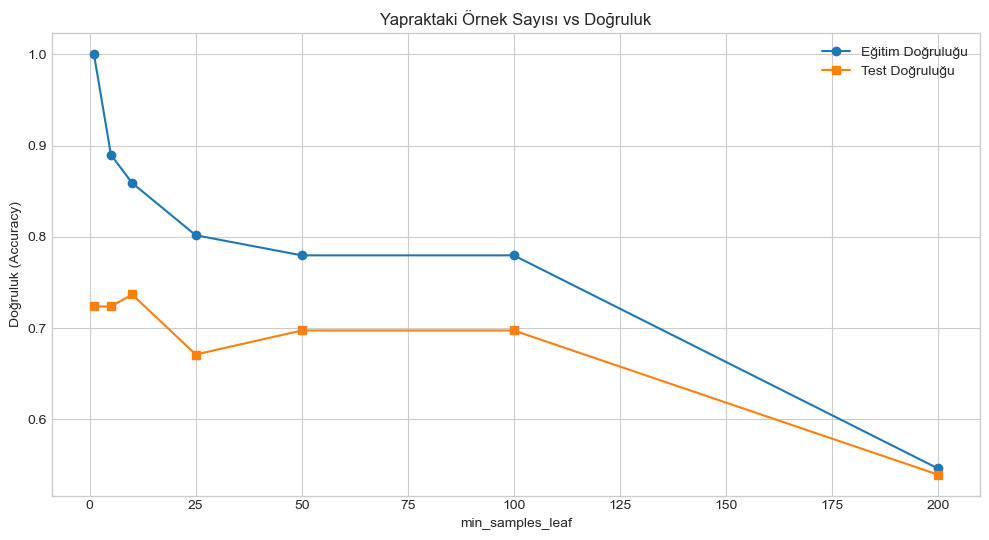

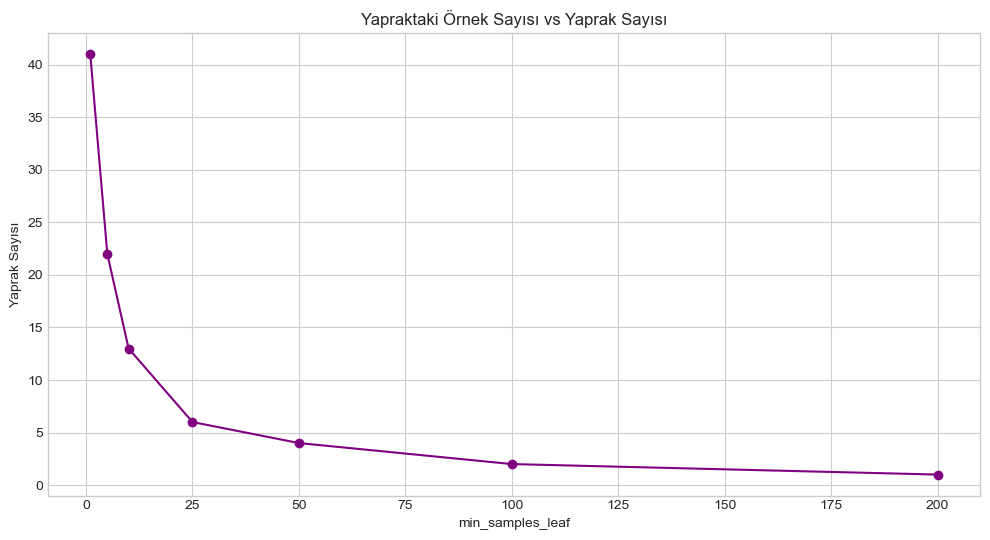


YORUM: Yapraktaki minimum örnek sayısı arttıkça, model daha basitleşiyor (yaprak sayısı azalıyor) ve test doğruluğu bu veriye göre değişiyor. Ama train ile test doğruluğu arasındaki fark azalıyor, bu da aşırı öğrenmenin azaldığını gösteriyor. Optimal min_samples_leaf değeri, test doğruluğunu maksimize eden değerdir.


In [54]:
print("\n==== Egzersiz 2: Yapraktaki Örnek Sayısı Etkisi ====")
min_samples_leaf_list = [1, 5, 10, 25, 50, 100, 200]
train_accs, test_accs, leaf_counts = [], [], []
for min_samples in min_samples_leaf_list:
    clf = DecisionTreeClassifier(criterion="gini", max_depth=10, min_samples_leaf=min_samples, random_state=RANDOM_STATE)
    clf.fit(X_heart_train, y_heart_train)
    train_accs.append(accuracy_score(y_heart_train, clf.predict(X_heart_train)))
    test_accs.append(accuracy_score(y_heart_test, clf.predict(X_heart_test)))
    leaf_counts.append(clf.get_n_leaves())
    print(f"min_samples_leaf={min_samples}: train_acc={train_accs[-1]:.4f}, test_acc={test_accs[-1]:.4f}, yaprak={leaf_counts[-1]}")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(min_samples_leaf_list, train_accs, marker='o', label='Eğitim Doğruluğu')
ax.plot(min_samples_leaf_list, test_accs, marker='s', label='Test Doğruluğu')
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("Doğruluk (Accuracy)")
ax.set_title("Yapraktaki Örnek Sayısı vs Doğruluk")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax2 = plt.subplots(figsize=(10, 5.5))
ax2.plot(min_samples_leaf_list, leaf_counts, marker='o', color='purple')
ax2.set_xlabel("min_samples_leaf")
ax2.set_ylabel("Yaprak Sayısı")
ax2.set_title("Yapraktaki Örnek Sayısı vs Yaprak Sayısı")
plt.tight_layout()
plt.show()

print("\nYORUM: Yapraktaki minimum örnek sayısı arttıkça, model daha basitleşiyor (yaprak sayısı azalıyor) ve test doğruluğu bu veriye göre değişiyor. Ama train ile test doğruluğu arasındaki fark azalıyor, bu da aşırı öğrenmenin azaldığını gösteriyor. Optimal min_samples_leaf değeri, test doğruluğunu maksimize eden değerdir.")

**E3 — Bike Sharing: `weather` bölünmesi için elle SSE azalması:** Bölüm 4'teki `yr` örneğine benzer şekilde, bu kez `weather` (GOOD/MISTY/BAD) özelliğini kullan. Basitleştirmek için `weather == 'GOOD'` vs `weather != 'GOOD'` ikili bölünmesini dene: her iki grubun ortalamasını, SSE'sini ve toplam SSE azalmasını hesapla (pandas ile, `bike` DataFrame'i üzerinde). Bu bölünme, Bölüm 4'teki `yr` bölünmesinden (%31.8 azalma) daha mı güçlü daha mı zayıf?

In [59]:
print("\n==== Egzersiz 3: SSE Azalması Hesabı ====")
# SSE Hesaplayalım: Kök SSE Hesabı
sse_root = np.var(y_bike_train, ddof=0) * len(y_bike_train)
# Hava bazında SSE hesabı içinse
# Good ve Good olmayan hava koşullarını ayıralım
good_weather = bike_train_r[bike_train_r['weather'] == 'GOOD']['cnt']
bad_weather = bike_train_r[bike_train_r['weather'] != 'GOOD']['cnt']
sse_good = np.var(good_weather, ddof=0) * len(good_weather)
sse_bad = np.var(bad_weather, ddof=0) * len(bad_weather)
sse_after = sse_good + sse_bad
sse_reduction = sse_root - sse_after
print(f"Kök SSE: {sse_root:.1f}")
print(f"Bolunme sonrasi toplam SSE: {sse_after:.1f}")
print(f"SSE Azalmasi: {sse_reduction:.1f} (%{sse_reduction/sse_root*100:.1f})")

print(f"\nYears'a göre daha az SSE azalttığı için weather'a göre ayırt etme daha az bilgi kazancı sağlıyor. Bu, karar ağacının hangi özelliği seçtiğini ve nedenini anlamamıza yardımcı olur.")


==== Egzersiz 3: SSE Azalması Hesabı ====
Kök SSE: 1841356743.1
Bolunme sonrasi toplam SSE: 1722195453.7
SSE Azalmasi: 119161289.4 (%6.5)

Years'a göre daha az SSE azalttığı için weather'a göre ayırt etme daha az bilgi kazancı sağlıyor. Bu, karar ağacının hangi özelliği seçtiğini ve nedenini anlamamıza yardımcı olur.


**E4 — Derinliğin karışıklık matrisine (confusion matrix) etkisi:** Heart Disease'te `max_depth=2` ve `max_depth=6` ile iki ayrı `DecisionTreeClassifier` eğit (Python 1'deki veriyle). İkisinin de test seti üzerindeki `confusion_matrix`'ini `ConfusionMatrixDisplay` ile yan yana çiz. Hangi derinlikte yanlış-negatif (hasta olup "hasta değil" denen) oranı daha düşük? Bu tür bir yanlışın (yanlış-negatif) tıbbi bağlamda neden yanlış-pozitiften daha maliyetli olabileceğini bir cümleyle tartış.


==== Egzersiz 4: Derinliğe Göre Karışıklık Matrisi ====

max_depth=2 için Karışıklık Matrisi:
Doğruluk: 0.6711, Yaprak Sayısı: 4, Derinlik: 2

max_depth=6 için Karışıklık Matrisi:
Doğruluk: 0.7105, Yaprak Sayısı: 29, Derinlik: 6

YORUM: Hasta diyipte hasta çıkmayan sayısı derinliği 2 olanda daha fazla çıkıyor, derinliği 6 olunca daha az çıkıyor. Bu, derinleştikçe modelin daha fazla ayrıntıyı öğrenmeye başladığını ve yanlış pozitiflerin azaldığını gösteriyor. Ancak aşırı derinleştikçe yanlış negatifler artabilir, bu yüzden optimal derinlik seçimi önemlidir.


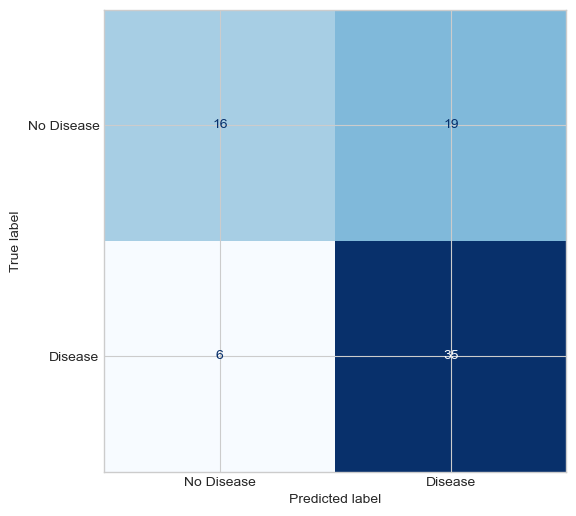

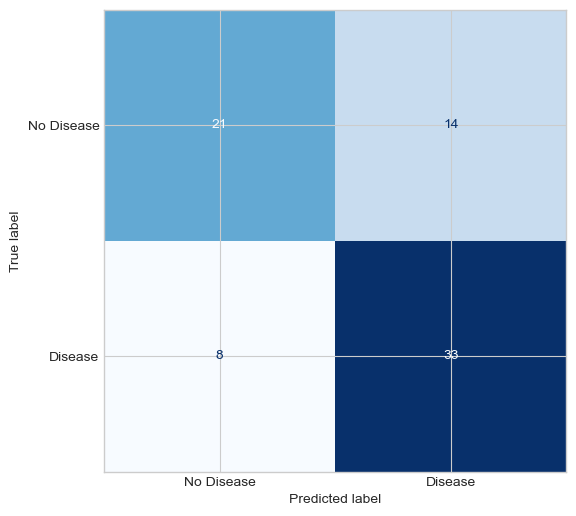

In [66]:
print("\n==== Egzersiz 4: Derinliğe Göre Karışıklık Matrisi ====")
depth_list = [2, 6]
for depth in depth_list:
    clf = DecisionTreeClassifier(criterion="gini", max_depth=depth, random_state=RANDOM_STATE)
    clf.fit(X_heart_train, y_heart_train)
    preds = clf.predict(X_heart_test)
    cm = ConfusionMatrixDisplay.from_predictions(y_heart_test, preds, cmap='Blues', colorbar=False,
                                                display_labels=["No Disease", "Disease"])
    print(f"\nmax_depth={depth} için Karışıklık Matrisi:\n{cm}")
    print(f"Doğruluk: {accuracy_score(y_heart_test, preds):.4f}, Yaprak Sayısı: {clf.get_n_leaves()}, Derinlik: {clf.get_depth()}")

print("\nYORUM: Hasta diyipte hasta çıkmayan sayısı derinliği 2 olanda daha fazla çıkıyor, derinliği 6 olunca daha az çıkıyor. Bu, derinleştikçe modelin daha fazla ayrıntıyı öğrenmeye başladığını ve yanlış pozitiflerin azaldığını gösteriyor. Ancak aşırı derinleştikçe yanlış negatifler artabilir, bu yüzden optimal derinlik seçimi önemlidir.")

**E5 — SQL'de Entropi/Bilgi Kazancı:** SQL1'deki Gini yaklaşımını genişleterek, DuckDB'de `sex` özelliğiyle (Adult Income, `adult` DataFrame'i) bölündüğünde **Entropi/Bilgi Kazancını** hesapla (`LOG(2, x)` fonksiyonunu kullanabilirsin — `LN(x)/LN(2)` şeklinde de yazılabilir). Python'da `entropy_impurity()` fonksiyonuyla (Python 2) aynı özellik için hesapladığın değerle karşılaştır.

In [84]:
print("\n==== Egzersiz 5: Sex'e Göre Entropi Kazancı Hesabı ====")
entropy_by_sql = '''
WITH grup_istatistikleri AS (
    SELECT
        sex,
        COUNT(*) AS n,
        AVG(CAST(target AS DOUBLE)) AS p1 -- p1 = target=1 olasılığı
    FROM heart_sql
    GROUP BY sex
),
entropy_hesap AS (
    SELECT
        sex,
        n,
        p1,
        -p1 * LOG(p1) - (1 - p1) * LOG(1 - p1) AS entropy
    FROM grup_istatistikleri
)
SELECT * FROM entropy_hesap ORDER BY sex
'''
entropy_by_sex = con.execute(entropy_by_sql).df()
print(entropy_by_sex)

root_entropy = entropy_impurity(y_heart_train)
weighted_entropy_sql = (entropy_by_sex['n'] * entropy_by_sex['entropy']).sum() / n_total
entropy_gain_sql = root_entropy - weighted_entropy_sql
print(f"\nKök Entropi (tum veri, N={n_total}): {root_entropy:.4f}")
print(f"Agirlikli Entropi (sex bolunmesi sonrasi, SQL): {weighted_entropy_sql:.4f}")
print(f"Entropi Kazanci (SQL): {entropy_gain_sql:.4f}")



==== Egzersiz 5: Sex'e Göre Entropi Kazancı Hesabı ====
   sex    n        p1   entropy
0    0   96  0.750000  0.244219
1    1  207  0.449275  0.298791

Kök Entropi (tum veri, N=303): 0.9938
Agirlikli Entropi (sex bolunmesi sonrasi, SQL): 0.2815
Entropi Kazanci (SQL): 0.7123


**E6 — MDI vs Permütasyon Önemi:** Adult Income'da Python 8'deki en iyi ön-budanmış modeli (`best_pre_pruned`) kullanarak `sklearn.inspection.permutation_importance()` ile izin-tabanlı özellik önemini hesapla (`n_repeats=10`, test verisi üzerinde). En önemli 10 özelliği Python 10'daki MDI sıralamasıyla karşılaştır — sıralama ne kadar değişiyor? Bölüm 6'daki "MDI yüksek-kardinaliteye yanlıdır" iddiasıyla tutarlı bir fark görüyor musun?

In [95]:
print("\n==== Egzersiz 6: MDI ve Permütasyon İlişkisi ====")

mdi = best_pre_pruned.feature_importances_
perm_importances = permutation_importance(best_pre_pruned, X_adult_test, y_adult_test, n_repeats=10, random_state=RANDOM_STATE)
perm_importances_df = pd.DataFrame({
    "Özellik": adult_feature_cols,
    "MDI": mdi,
    "Permütasyon Önem": perm_importances.importances_mean
}).sort_values(by="Permütasyon Önem", ascending=False)
print(perm_importances_df.head(10).to_string(index=False))

print("\nYORUM: MDI ve permütasyon önem sıralamaları genellikle benzer sonuçlar verir, ancak permütasyon yöntemi modelin tahmin performansına doğrudan etkisini ölçerken, MDI sadece ağacın yapısal özelliklerine dayanır. Bu nedenle, bazı özellikler MDI'de yüksek önem taşıyabilirken, permütasyon öneminde daha düşük olabilir ve bunun tersi de geçerlidir.")


==== Egzersiz 6: MDI ve Permütasyon İlişkisi ====
                          Özellik      MDI  Permütasyon Önem
marital_status_Married-civ-spouse 0.396281          0.050230
                    education_num 0.220150          0.047047
                     capital_gain 0.189239          0.045552
                              age 0.041463          0.014239
                     capital_loss 0.068399          0.012499
                   hours_per_week 0.030488          0.009039
       occupation_Exec-managerial 0.010104          0.004361
         occupation_Other-service 0.004315          0.001955
                education_Masters 0.002958          0.001474
                relationship_Wife 0.003164          0.001034

YORUM: MDI ve permütasyon önem sıralamaları genellikle benzer sonuçlar verir, ancak permütasyon yöntemi modelin tahmin performansına doğrudan etkisini ölçerken, MDI sadece ağacın yapısal özelliklerine dayanır. Bu nedenle, bazı özellikler MDI'de yüksek önem taşıyabilirken, perm

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees.* Wadsworth. | Bölüm 1-6 (tüm teori) | CART algoritmasını tanıtan orijinal kitap — Gini, budama, regresyon ağaçları |
| Quinlan, J. R. (1986). *Induction of Decision Trees.* Machine Learning, 1(1), 81-106. | Bölüm 2 | ID3 algoritması ve Entropi/Bilgi Kazancı kriterinin kaynağı |
| [scikit-learn — Decision Trees User Guide](https://scikit-learn.org/stable/modules/tree.html) | Teori + API (tüm bölümler) | `DecisionTreeClassifier`/`Regressor`, `cost_complexity_pruning_path` resmi dokümantasyonu |
| Hastie, T., Tibshirani, R., & Friedman, J. *The Elements of Statistical Learning*, Ch. 9. [Ücretsiz PDF](https://hastie.su.domains/ElemStatLearn/) | Bölüm 1-6 | CART'ın matematiksel türetimi, maliyet-karmaşıklık budaması |
| James, G., Witten, D., Hastie, T., & Tibshirani, R. *An Introduction to Statistical Learning*, Ch. 8. [Ücretsiz PDF](https://www.statlearning.com/) | Bölüm 1-6 | Daha sezgisel/uygulamalı bir CART anlatımı, R örnekleriyle |
| Molnar, C. *Interpretable Machine Learning*, Ch. 5.2 (Decision Tree). [Ücretsiz kitap](https://christophmolnar.com/books/interpretable-machine-learning/) | Bölüm 6, Python 11-14 | Yorumlanabilirlik odaklı anlatım; Bike Sharing veri setinin kaynağı |
| [CRAN — `rpart` paketi dokümantasyonu](https://cran.r-project.org/web/packages/rpart/rpart.pdf) | R Uygulaması | `rpart()`, `printcp()`, `prune()` fonksiyonlarının resmi referansı |
| Therneau, T., & Atkinson, E. (2023). *An Introduction to Recursive Partitioning Using the RPART Routines.* [PDF](https://cran.r-project.org/web/packages/rpart/vignettes/longintro.pdf) | R Uygulaması | `rpart`'ın maliyet-karmaşıklık budaması ve kategorik bölünme mantığının ayrıntılı açıklaması |
| [DuckDB — Aggregate Functions](https://duckdb.org/docs/sql/functions/aggregates) | SQL Uygulaması | `VAR_POP`, `AVG` gibi SQL1-2'de kullanılan toplama fonksiyonları |
| [UCI ML Repository — Heart Disease Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) | Python 1-5 (Heart Disease) | Orijinal veri seti sayfası (Detrano et al., 1989 — Cleveland Clinic) |
| [UCI ML Repository — Adult (Census Income) Dataset](https://archive.ics.uci.edu/dataset/2/adult) | Python 6-10 (Adult Income) | Orijinal veri seti sayfası (Kohavi, 1996) |
| [UCI ML Repository — Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) | Python 11-14 (Bike Sharing) | Orijinal veri seti sayfası (Fanaee-T & Gama, 2013) |
| [jbrownlee/Datasets (GitHub)](https://github.com/jbrownlee/Datasets) | Adult Income veri yükleme | Bu notebook'ta fiilen Adult Income'ı çekmek için kullanılan GitHub mirror |
| [christophM/interpretable-ml-book (GitHub)](https://github.com/christophM/interpretable-ml-book) | Bike Sharing veri yükleme | Bu notebook'ta fiilen Bike Sharing'i çekmek için kullanılan, temizlenmiş mirror (orijinal kaynak yukarıdaki UCI sayfası) |
| [StatQuest with Josh Starmer — Decision and Classification Trees (YouTube serisi)](https://www.youtube.com/watch?v=_L39rN6gz7Y) | Bölüm 1-3 | Gini impuritesinin ve ağaç kurma sürecinin görsel/sezgisel anlatımı |
| [Google Developers — Decision Forests (Yorumlanabilirlik ve Feature Importance)](https://developers.google.com/machine-learning/decision-forests) | Bölüm 6 | MDI'nin pratik sınırlamaları ve permütasyon önemi üzerine endüstri odaklı rehber |